In [4]:
import duckdb
import pandas as pd

con = duckdb.connect()

qcew_path = r"C:\Users\Matthias\Documents\Local Finance Projects\American_Economic_Data_Repository\02_Labor_Income\AEDR_QCEW_Analytical_Final.parquet"

In [5]:
sector_check = con.execute(f"""
    SELECT DISTINCT
        industry_code,
        industry_title,
        industry_detail_level,
        sector_code
    FROM read_parquet('{qcew_path}')
    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
    ORDER BY industry_code
""").df()

sector_check

,industry_code,industry_title,industry_detail_level,sector_code
0,11,"NAICS 11 Agriculture, forestry, fishing and hu...",NAICS Sector (2-digit),11
1,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",NAICS Sector (2-digit),21
2,22,NAICS 22 Utilities,NAICS Sector (2-digit),22
3,23,NAICS 23 Construction,NAICS Sector (2-digit),23
4,31-33,NAICS 31-33 Manufacturing,NAICS Sector (2-digit),31-33
5,42,NAICS 42 Wholesale trade,NAICS Sector (2-digit),42
6,44-45,NAICS 44-45 Retail trade,NAICS Sector (2-digit),44-45
7,48-49,NAICS 48-49 Transportation and warehousing,NAICS Sector (2-digit),48-49
8,51,NAICS 51 Information,NAICS Sector (2-digit),51
9,52,NAICS 52 Finance and insurance,NAICS Sector (2-digit),52


In [6]:
sector_year_check = con.execute(f"""
    SELECT
        year,
        COUNT(DISTINCT industry_code) AS sector_count
    FROM read_parquet('{qcew_path}')
    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
    GROUP BY year
    ORDER BY year
""").df()

sector_year_check

,year,sector_count
0,1990,20
1,1991,20
2,1992,20
3,1993,20
4,1994,20
5,1995,20
6,1996,20
7,1997,20
8,1998,20
9,1999,20


In [7]:
sector_boundary_check = con.execute(f"""
    SELECT
        industry_code,
        industry_title,
        MAX(CASE WHEN year = 2000 THEN 1 ELSE 0 END) AS present_2000,
        MAX(CASE WHEN year = 2001 THEN 1 ELSE 0 END) AS present_2001
    FROM read_parquet('{qcew_path}')
    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
      AND year IN (2000, 2001)
    GROUP BY industry_code, industry_title
    HAVING present_2000 <> present_2001
    ORDER BY industry_code
""").df()

sector_boundary_check

,industry_code,industry_title,present_2000,present_2001
0,99,NAICS 99 Unclassified,0,1


## National 2-Digit NAICS Analytical Slice — Initial Validation

The first Question 2 analytical dataset is being developed at the proposed grain:

**Year × National Geography × 2-Digit NAICS Sector × Ownership**

Before constructing the analytical panel or calculating wage shares, employment shares,
growth rates, or other derived measures, the underlying sector structure was inspected
directly from `AEDR_QCEW_Analytical_Final.parquet`.

### Industry Structure

At the national level, the analytical Parquet contains 21 distinct classifications identified
as `NAICS Sector (2-digit)` across the complete 1990–2025 period.

These records represent the broad NAICS sector level of the industry hierarchy, including
sectors such as Agriculture, Construction, Manufacturing, Finance and Insurance,
Professional, Scientific, and Technical Services, Educational Services, Health Care and
Social Assistance, and Public Administration.

The sector structure also correctly preserves the combined NAICS sector identifiers:

- 31-33 — Manufacturing
- 44-45 — Retail Trade
- 48-49 — Transportation and Warehousing

These combined identifiers are part of the 2-digit sector-level classification and should not
be interpreted as lower-level industry codes.

The analytical `sector_code` agrees with `industry_code` for the inspected national
2-digit sector records. No unexpected sector-code mappings were identified.

### Historical Sector Coverage

Sector coverage is not identical across the complete historical period:

- **1990–2000:** 20 distinct national 2-digit sector classifications
- **2001–2025:** 21 distinct national 2-digit sector classifications

A direct comparison of the 2000 and 2001 sector universes established that the only
additional classification is:

**NAICS 99 — Unclassified**

NAICS 99 is absent from the national 2-digit sector records through 2000 and appears
beginning in 2001.

The 20 substantive classified sectors represented during 1990–2000 remain represented
after the 2001 boundary. The increase from 20 to 21 classifications therefore results
from the appearance of NAICS 99 rather than the addition or disappearance of one of
the substantive classified economic sectors.

### Consistency With AEDR Engineering

This result is consistent with the historical QCEW structure previously identified and
documented during AEDR database engineering.

The QCEW Engineering Audit established 2001 as an important source-data boundary.
BLS QCEW data through 2000 were historically reconstructed into NAICS, while 2001
was the first official QCEW reference year produced natively under NAICS. The
engineering audit also established that the reconstructed historical files do not contain
the same reporting detail as the native 2001-forward files.

AEDR intentionally preserved these legitimate historical source differences rather than
artificially forcing the earlier records to reproduce the later reporting structure.

The absence of NAICS 99 during 1990–2000 is therefore being treated as a preserved
historical source characteristic, not as evidence of Parquet materialization failure,
missing-data corruption, or an analytical transformation error.

### Analytical Treatment

NAICS 99 will remain in the dataset during the current validation stage.

No artificial NAICS 99 observations will be created for 1990–2000, and the absence of
those observations will not be interpreted as zero economic activity.

No exclusion of NAICS 99 will be made at this stage. If later substantive analysis
requires restricting comparisons to classified economic sectors, exclusion of NAICS 99
will be treated as an explicit analytical decision and documented separately.

### Validation Status

**Industry-code structure: PASS**

**Historical sector coverage: PASS — NAICS 99 begins in 2001, consistent with the
documented historical QCEW/NAICS structure preserved during AEDR engineering.**

The analytical Parquet is behaving consistently with the relevant source-structure and
engineering decisions established during construction.

Ownership coverage, observation uniqueness, and aggregation behavior for the proposed
National × 2-Digit NAICS × Ownership × Year slice have not yet been validated.

In [8]:
ownership_check = con.execute(f"""
    SELECT
        own_code,
        own_title,
        COUNT(*) AS row_count,
        MIN(year) AS first_year,
        MAX(year) AS last_year,
        COUNT(DISTINCT year) AS years_present,
        COUNT(DISTINCT industry_code) AS sectors_present
    FROM read_parquet('{qcew_path}')
    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
    GROUP BY own_code, own_title
    ORDER BY own_code
""").df()

ownership_check

,own_code,own_title,row_count,first_year,last_year,years_present,sectors_present
0,1,Federal Government,650,1990,2025,36,19
1,2,State Government,663,1990,2025,36,19
2,3,Local Government,701,1990,2025,36,21
3,5,Private,709,1990,2025,36,20


In [9]:
ownership_sector_check = con.execute(f"""
    SELECT
        own_code,
        own_title,
        industry_code,
        industry_title,
        MIN(year) AS first_year,
        MAX(year) AS last_year,
        COUNT(DISTINCT year) AS years_present
    FROM read_parquet('{qcew_path}')
    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
      AND own_code IN (1, 2, 3, 5)
    GROUP BY
        own_code,
        own_title,
        industry_code,
        industry_title
    ORDER BY
        own_code,
        industry_code
""").df()

ownership_sector_check

,own_code,own_title,industry_code,industry_title,first_year,last_year,years_present
0,1,Federal Government,11,"NAICS 11 Agriculture, forestry, fishing and hu...",1990,2025,36
1,1,Federal Government,22,NAICS 22 Utilities,1990,2025,36
2,1,Federal Government,23,NAICS 23 Construction,1990,2025,36
3,1,Federal Government,31-33,NAICS 31-33 Manufacturing,1990,2025,36
4,1,Federal Government,42,NAICS 42 Wholesale trade,2003,2024,13
...,...,...,...,...,...,...,...
74,5,Private,62,NAICS 62 Health care and social assistance,1990,2025,36
75,5,Private,71,"NAICS 71 Arts, entertainment, and recreation",1990,2025,36
76,5,Private,72,NAICS 72 Accommodation and food services,1990,2025,36
77,5,Private,81,NAICS 81 Other services (except public adminis...,1990,2025,36


In [10]:
ownership_sector_gaps = con.execute(f"""
    SELECT
        own_code,
        own_title,
        industry_code,
        industry_title,
        MIN(year) AS first_year,
        MAX(year) AS last_year,
        COUNT(DISTINCT year) AS years_present,
        CASE
            WHEN industry_code = '99' THEN 25
            ELSE 36
        END AS expected_years
    FROM read_parquet('{qcew_path}')
    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
      AND own_code IN (1, 2, 3, 5)
    GROUP BY
        own_code,
        own_title,
        industry_code,
        industry_title
    HAVING COUNT(DISTINCT year) <
        CASE
            WHEN industry_code = '99' THEN 25
            ELSE 36
        END
    ORDER BY
        own_code,
        industry_code
""").df()

ownership_sector_gaps

,own_code,own_title,industry_code,industry_title,first_year,last_year,years_present,expected_years
0,1,Federal Government,42,NAICS 42 Wholesale trade,2003,2024,13,36
1,2,State Government,42,NAICS 42 Wholesale trade,1990,2023,26,36
2,3,Local Government,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",1994,2025,32,36
3,3,Local Government,31-33,NAICS 31-33 Manufacturing,1993,2025,31,36
4,3,Local Government,55,NAICS 55 Management of companies and enterprises,2001,2001,1,36


In [11]:
absent_ownership_sectors = con.execute(f"""
    WITH sectors AS (
        SELECT DISTINCT
            industry_code,
            industry_title
        FROM read_parquet('{qcew_path}')
        WHERE geography_level = 'National'
          AND industry_detail_level = 'NAICS Sector (2-digit)'
    ),
    ownerships AS (
        SELECT DISTINCT
            own_code,
            own_title
        FROM read_parquet('{qcew_path}')
        WHERE geography_level = 'National'
          AND industry_detail_level = 'NAICS Sector (2-digit)'
          AND own_code IN (1, 2, 3, 5)
    ),
    observed AS (
        SELECT DISTINCT
            own_code,
            industry_code
        FROM read_parquet('{qcew_path}')
        WHERE geography_level = 'National'
          AND industry_detail_level = 'NAICS Sector (2-digit)'
          AND own_code IN (1, 2, 3, 5)
    )
    SELECT
        o.own_code,
        o.own_title,
        s.industry_code,
        s.industry_title
    FROM ownerships o
    CROSS JOIN sectors s
    LEFT JOIN observed x
        ON o.own_code = x.own_code
       AND s.industry_code = x.industry_code
    WHERE x.industry_code IS NULL
    ORDER BY
        o.own_code,
        s.industry_code
""").df()

absent_ownership_sectors

,own_code,own_title,industry_code,industry_title
0,1,Federal Government,21,"NAICS 21 Mining, quarrying, and oil and gas ex..."
1,1,Federal Government,55,NAICS 55 Management of companies and enterprises
2,2,State Government,21,"NAICS 21 Mining, quarrying, and oil and gas ex..."
3,2,State Government,55,NAICS 55 Management of companies and enterprises
4,5,Private,92,NAICS 92 Public administration


In [12]:
partial_year_detail = con.execute(f"""
    SELECT
        own_code,
        own_title,
        industry_code,
        industry_title,
        LIST(year ORDER BY year) AS years_present
    FROM read_parquet('{qcew_path}')
    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
      AND (
            (own_code = 1 AND industry_code = '42')
         OR (own_code = 2 AND industry_code = '42')
         OR (own_code = 3 AND industry_code = '21')
         OR (own_code = 3 AND industry_code = '31-33')
         OR (own_code = 3 AND industry_code = '55')
      )
    GROUP BY
        own_code,
        own_title,
        industry_code,
        industry_title
    ORDER BY
        own_code,
        industry_code
""").df()

partial_year_detail

,own_code,own_title,industry_code,industry_title,years_present
0,1,Federal Government,42,NAICS 42 Wholesale trade,"[2003, 2004, 2005, 2006, 2007, 2008, 2009, 201..."
1,2,State Government,42,NAICS 42 Wholesale trade,"[1990, 1991, 1992, 1993, 1994, 1995, 1998, 200..."
2,3,Local Government,21,"NAICS 21 Mining, quarrying, and oil and gas ex...","[1994, 1995, 1996, 1997, 1998, 1999, 2000, 200..."
3,3,Local Government,31-33,NAICS 31-33 Manufacturing,"[1993, 1995, 1997, 1998, 1999, 2000, 2001, 200..."
4,3,Local Government,55,NAICS 55 Management of companies and enterprises,[2001]


## National 2-Digit NAICS Analytical Slice — Ownership Coverage Validation

Ownership coverage was evaluated for the proposed national 2-digit NAICS analytical
slice using the four component QCEW ownership categories:

- 1 — Federal Government
- 2 — State Government
- 3 — Local Government
- 5 — Private

BLS identifies these as the component ownership sectors in NAICS-coded QCEW data.
BLS also publishes aggregate ownership categories such as Total Covered (0) and
Total Government (8), but those aggregate categories are not being treated as additive
ownership components in this analytical slice.

**BLS source:**  
https://www.bls.gov/cew/classifications/ownerships/ownership-titles.htm

### Ownership Time Coverage

All four component ownership categories are represented somewhere in the national
2-digit sector data in every year from 1990 through 2025.

Initial coverage counts were:

- Federal Government: 650 records, 36 years, 19 sectors represented
- State Government: 663 records, 36 years, 19 sectors represented
- Local Government: 701 records, 36 years, 21 sectors represented
- Private: 709 records, 36 years, 20 sectors represented

The presence of each ownership category across all 36 years does not imply that every
ownership × sector combination exists in every year.

### Completely Absent Ownership × Sector Combinations

Five ownership × sector combinations contain no observations anywhere in the
1990–2025 national 2-digit sector data:

- Federal Government × NAICS 21 — Mining, Quarrying, and Oil and Gas Extraction
- Federal Government × NAICS 55 — Management of Companies and Enterprises
- State Government × NAICS 21 — Mining, Quarrying, and Oil and Gas Extraction
- State Government × NAICS 55 — Management of Companies and Enterprises
- Private × NAICS 92 — Public Administration

These combinations are absent from the source-derived analytical records rather than
represented by observations containing zero employment or wages.

### Partial Ownership × Sector Coverage

Five additional ownership × sector combinations occur during only part of their
theoretically available historical period:

- Federal Government × NAICS 42 — Wholesale Trade: 13 of 36 years
- State Government × NAICS 42 — Wholesale Trade: 26 of 36 years
- Local Government × NAICS 21 — Mining, Quarrying, and Oil and Gas Extraction:
  32 of 36 years
- Local Government × NAICS 31-33 — Manufacturing: 31 of 36 years
- Local Government × NAICS 55 — Management of Companies and Enterprises:
  1 of 36 years

Inspection of the available year lists showed that these partial series are not uniformly
explained by a single beginning or ending publication year. At least some exhibit
intermittent historical coverage. Local Government × NAICS 55 appears only in 2001.

### BLS Publication Structure and Missing Cells

BLS documentation confirms that QCEW data are organized around combinations of
geography, ownership, and industry and that not every possible combination necessarily
exists in every period.

BLS specifically distinguishes between a QCEW cell that **does not exist** and a cell
that exists but is **suppressed for confidentiality**.

For the 2001–2003 QCEW files, BLS states that a dash indicates that the macro cell
does not exist for the specific quarter and year. BLS further explains that cells that do
not exist do not require suppression because no corresponding observation exists in
the files.

Suppression is a different condition. When an existing cell is withheld for disclosure
reasons, BLS uses the disclosure code `N`, and affected economic values may be
unavailable or zero-filled in the source publication files.

The historical 1990–2000 reconstructed NAICS files require additional caution. BLS
states that these files were reconstructed from data originally published under SIC and
that, for this period, a dash can represent either a nonexistent cell or a suppressed cell.
BLS also notes that most suppressed cells were not included in these historical files.

**BLS source:**  
https://www.bls.gov/cew/questions-and-answers.htm

BLS aggregation documentation further states that many QCEW aggregation levels
provide data for **one or several ownership sectors**, including Federal, State, Local,
and Private ownership. This supports treating ownership-sector availability as part of
the QCEW reporting structure rather than assuming that every industry must contain
all four ownership categories.

**BLS source:**  
https://www.bls.gov/cew/classifications/aggregation/agg-level-titles.htm

### Consistency With AEDR Engineering

The observed ownership coverage is consistent with the source-preserving design used
during AEDR QCEW engineering.

AEDR preserved the BLS source observation structure rather than manufacturing missing
ownership × industry × year combinations to create a balanced panel. Previous QCEW
engineering validation also established that the annual source records were unique at
their identifying categorical grain.

The ownership-sector gaps identified during this analysis therefore do not provide
evidence of accidental row loss, Parquet materialization failure, or corruption introduced
during AEDR engineering.

Instead, the analytical Parquet preserves the availability of the underlying QCEW
source-derived cells.

For 2001-forward data, the absence of a source cell can be distinguished conceptually
from disclosure suppression under the BLS documentation. For reconstructed
1990–2000 NAICS data, the historical publication structure makes that distinction less
straightforward, and absent historical observations should therefore not be assigned a
more specific cause without additional source evidence.

### Analytical Treatment

The National × 2-Digit NAICS × Ownership × Year dataset must be treated as an
**unbalanced panel**.

An absent ownership-sector-year observation will not automatically be interpreted as:

- zero employment,
- zero wages,
- zero economic activity, or
- a suppressed observation.

No synthetic zero-valued records will be created merely to balance the panel.

Future longitudinal calculations must verify that the required observations exist before
calculating changes or growth rates. Where historical comparisons depend on absent
cells, the coverage limitation must be retained rather than silently imputed.

Disclosure codes and other source indicators should be used where necessary to
distinguish published observations with withheld values from combinations for which no
analytical observation exists.

### Validation Status

**Ownership-category time coverage: PASS — all four component ownership categories
are represented across 1990–2025.**

**Ownership × sector coverage: PASS WITH DOCUMENTED QCEW COVERAGE LIMITATIONS —
five combinations are completely absent and five additional combinations have partial
historical coverage.**

**BLS documentation consistency: PASS — BLS documentation confirms that QCEW cells
may not exist for particular geography × ownership × industry × period combinations and
distinguishes nonexistent cells from disclosure-suppressed cells. Historical reconstructed
1990–2000 NAICS files require additional caution because absent and suppressed cells are
not always distinguishable from file presence alone.**

**AEDR engineering consistency: PASS — the analytical Parquet preserves the underlying
source-derived observation structure rather than artificially balancing ownership-sector
coverage.**

The ownership structure is suitable for continued descriptive analysis provided that the
panel remains unbalanced and absent observations are not silently converted to zero.

Observation uniqueness and aggregation behavior for the proposed
National × 2-Digit NAICS × Ownership × Year slice remain to be validated.

In [13]:
grain_check = con.execute(f"""
    SELECT
        year,
        industry_code,
        own_code,
        COUNT(*) AS observation_count
    FROM read_parquet('{qcew_path}')
    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
      AND own_code IN (1, 2, 3, 5)
    GROUP BY
        year,
        industry_code,
        own_code
    HAVING COUNT(*) > 1
    ORDER BY
        year,
        industry_code,
        own_code
""").df()

grain_check

,year,industry_code,own_code,observation_count


## National 2-Digit NAICS Analytical Slice — Observation Grain Validation

The proposed analytical grain was tested for duplicate observations using:

**Year × National Geography × 2-Digit NAICS Sector × Ownership**

The validation grouped all observations in the national 2-digit sector slice by:

- `year`
- `industry_code`
- `own_code`

and searched for combinations containing more than one record.

### Result

**Zero duplicate combinations were identified.**

Whenever a National × 2-Digit NAICS Sector × Ownership × Year combination exists,
it is represented by exactly one observation in the analytical Parquet.

This result is distinct from the previously documented ownership coverage limitations.
Some ownership × sector × year combinations do not exist in the source-derived data,
but existing combinations are not duplicated.

Therefore:

- zero rows may represent an absent source-derived cell,
- one row represents an existing observation,
- no combinations containing more than one row were detected.

### Consistency With AEDR Engineering

This result is consistent with the previous QCEW Engineering Audit.

The source-level engineering audit established that QCEW annual records from
1990–2025 contained no duplicate identifier combinations at the validated source grain.
The current analytical validation confirms that selecting the National × 2-Digit NAICS
× Ownership slice does not introduce a hidden lower-level dimension or produce
duplicate observations at the proposed Question 2 analytical grain.

### Validation Status

**Observation uniqueness: PASS — zero duplicate analytical-grain combinations detected.**

**Analytical grain: PASS — existing observations are uniquely represented at
Year × National Geography × 2-Digit NAICS Sector × Ownership.**

The proposed grain is suitable for continued descriptive analysis.

Aggregation behavior remains to be validated before the initial national 2-digit
analytical slice is considered fully validated.

In [14]:
sector_ownership_reconciliation = con.execute(f"""
    SELECT
        year,
        industry_code,
        industry_title,

        MAX(CASE WHEN own_code = 0
                 THEN annual_avg_emplvl END) AS total_covered_employment,

        SUM(CASE WHEN own_code IN (1, 2, 3, 5)
                 THEN annual_avg_emplvl END) AS component_employment,

        MAX(CASE WHEN own_code = 0
                 THEN total_annual_wages END) AS total_covered_wages,

        SUM(CASE WHEN own_code IN (1, 2, 3, 5)
                 THEN total_annual_wages END) AS component_wages

    FROM read_parquet('{qcew_path}')

    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
      AND own_code IN (0, 1, 2, 3, 5)

    GROUP BY
        year,
        industry_code,
        industry_title

    ORDER BY
        year,
        industry_code
""").df()

sector_ownership_reconciliation.head(20)

,year,industry_code,industry_title,total_covered_employment,component_employment,total_covered_wages,component_wages
0,1990,11,"NAICS 11 Agriculture, forestry, fishing and hu...",<NA>,1093997.0,<NA>,1.539464e+10
1,1990,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",<NA>,662721.0,<NA>,2.472192e+10
2,1990,22,NAICS 22 Utilities,<NA>,999374.0,<NA>,3.717004e+10
3,1990,23,NAICS 23 Construction,<NA>,5386716.0,<NA>,1.413970e+11
4,1990,31-33,NAICS 31-33 Manufacturing,<NA>,17913919.0,<NA>,5.026576e+11
5,1990,42,NAICS 42 Wholesale trade,<NA>,5177587.0,<NA>,1.585874e+11
6,1990,44-45,NAICS 44-45 Retail trade,<NA>,13484035.0,<NA>,2.093570e+11
7,1990,48-49,NAICS 48-49 Transportation and warehousing,<NA>,4263742.0,<NA>,1.172797e+11
8,1990,51,NAICS 51 Information,<NA>,2900381.0,<NA>,9.048071e+10
9,1990,52,NAICS 52 Finance and insurance,<NA>,5106315.0,<NA>,1.589477e+11


In [15]:
total_covered_structure = con.execute(f"""
    SELECT
        industry_detail_level,
        COUNT(*) AS row_count,
        COUNT(DISTINCT year) AS years_present,
        MIN(year) AS first_year,
        MAX(year) AS last_year,
        COUNT(DISTINCT industry_code) AS industry_codes
    FROM read_parquet('{qcew_path}')
    WHERE geography_level = 'National'
      AND own_code = 0
    GROUP BY industry_detail_level
    ORDER BY industry_detail_level
""").df()

total_covered_structure

,industry_detail_level,row_count,years_present,first_year,last_year,industry_codes
0,All industries / aggregate total,36,36,1990,2025,1


In [16]:
private_sector_reconciliation = con.execute(f"""
    WITH sector_sum AS (
        SELECT
            year,
            SUM(annual_avg_emplvl) AS sector_employment,
            SUM(total_annual_wages) AS sector_wages
        FROM read_parquet('{qcew_path}')
        WHERE geography_level = 'National'
          AND industry_detail_level = 'NAICS Sector (2-digit)'
          AND own_code = 5
        GROUP BY year
    ),

    all_industries AS (
        SELECT
            year,
            annual_avg_emplvl AS published_employment,
            total_annual_wages AS published_wages
        FROM read_parquet('{qcew_path}')
        WHERE geography_level = 'National'
          AND industry_detail_level = 'All industries / aggregate total'
          AND own_code = 5
    )

    SELECT
        s.year,
        s.sector_employment,
        a.published_employment,
        s.sector_employment - a.published_employment AS employment_difference,
        s.sector_wages,
        a.published_wages,
        s.sector_wages - a.published_wages AS wage_difference
    FROM sector_sum s
    JOIN all_industries a
        ON s.year = a.year
    ORDER BY s.year
""").df()

private_sector_reconciliation

,year,sector_employment,published_employment,employment_difference,sector_wages,published_wages,wage_difference
0,1990,90771117.0,90855141,-84024.0,2.111834e+12,2113480141080,-1.645933e+09
1,1991,88882066.0,88959123,-77057.0,2.152668e+12,2154378854007,-1.710368e+09
2,1992,89191225.0,89270154,-78929.0,2.285563e+12,2287422017304,-1.859322e+09
3,1993,91096386.0,91182537,-86151.0,2.365837e+12,2367851706058,-2.014491e+09
4,1994,93960014.0,94046402,-86388.0,2.493361e+12,2495394753637,-2.033589e+09
5,1995,96717342.0,96813394,-96052.0,2.711733e+12,2714083573907,-2.350772e+09
6,1996,99026503.0,99132077,-105574.0,2.834842e+12,2837782187037,-2.940405e+09
7,1997,102065073.0,102180759,-115686.0,3.130848e+12,3133935564858,-3.087710e+09
8,1998,104856127.0,104998092,-141965.0,3.334499e+12,3338711098223,-4.211683e+09
9,1999,107353456.0,107545977,-192521.0,3.588564e+12,3594747185576,-6.183324e+09


In [17]:
private_sector_reconciliation["employment_difference_pct"] = (
    private_sector_reconciliation["employment_difference"]
    / private_sector_reconciliation["published_employment"]
    * 100
)

private_sector_reconciliation["wage_difference_pct"] = (
    private_sector_reconciliation["wage_difference"]
    / private_sector_reconciliation["published_wages"]
    * 100
)

private_sector_reconciliation[
    [
        "year",
        "employment_difference",
        "employment_difference_pct",
        "wage_difference",
        "wage_difference_pct"
    ]
]

,year,employment_difference,employment_difference_pct,wage_difference,wage_difference_pct
0,1990,-84024.0,-9.248128e-02,-1.645933e+09,-0.077878
1,1991,-77057.0,-8.662068e-02,-1.710368e+09,-0.079390
2,1992,-78929.0,-8.841589e-02,-1.859322e+09,-0.081285
3,1993,-86151.0,-9.448191e-02,-2.014491e+09,-0.085077
4,1994,-86388.0,-9.185678e-02,-2.033589e+09,-0.081494
5,1995,-96052.0,-9.921354e-02,-2.350772e+09,-0.086614
6,1996,-105574.0,-1.064983e-01,-2.940405e+09,-0.103616
7,1997,-115686.0,-1.132170e-01,-3.087710e+09,-0.098525
8,1998,-141965.0,-1.352072e-01,-4.211683e+09,-0.126147
9,1999,-192521.0,-1.790127e-01,-6.183324e+09,-0.172010


## National 2-Digit NAICS Analytical Slice — Aggregation Validation

Aggregation behavior was tested by determining whether the available National
2-Digit NAICS sector observations reconstruct the corresponding published
National All-Industries total.

Because `own_code = 0` (Total Covered) is represented at the National
All-Industries level but is not available as a National 2-Digit NAICS sector
observation in the analytical dataset, a direct sector-level reconciliation
against Total Covered cannot be performed.

The aggregation test was therefore conducted using Private ownership
(`own_code = 5`), for which the National 2-Digit sector observations can be
summed and compared with the independently published National Private
All-Industries observation.

The following measures were evaluated:

- Annual average employment
- Total annual wages

### 2001–2025 Results

Beginning in 2001, the National Private 2-Digit sector observations reconstruct
the published National Private All-Industries totals essentially exactly.

For total annual wages:

- The summed 2-digit sector wages equal the published Private All-Industries
  wage total exactly in every year from 2001 through 2025.
- The observed wage difference is $0 in all 25 years.

For annual average employment:

- Differences range only from -1 to +3 workers.
- Several years reconcile exactly.
- Percentage differences are effectively zero, on the order of approximately
  one-millionth of one percent.

These extremely small employment differences are consistent with aggregation
of independently reported annual-average employment values and do not represent
a material analytical discrepancy.

The 2001–2025 results provide strong evidence that the National 2-Digit NAICS
Private-sector observations aggregate correctly to the independently published
National Private All-Industries control.

### 1990–2000 Results

The reconstructed 1990–2000 NAICS period behaves differently.

During these years, the sum of the available National Private 2-Digit sectors
falls below the published National Private All-Industries total for both
employment and wages.

Employment differences range from:

- -77,057 workers in 1991, approximately -0.087%
- to -319,571 workers in 2000, approximately -0.290%

Wage differences range from approximately:

- -$1.65 billion in 1990, approximately -0.078%
- to -$11.36 billion in 2000, approximately -0.292%

Although these differences remain below approximately 0.30% of the published
Private totals, they are materially larger than the effectively zero differences
observed beginning in 2001.

### Historical Structure Interpretation

The sharp change in reconciliation behavior occurs exactly at the previously
documented 2000–2001 QCEW structural boundary.

The AEDR QCEW engineering audit established that the 1990–2000 files are
historical NAICS reconstructions derived from data originally published under
the SIC classification system. Those reconstructed files do not contain the
same level of industry coverage available in the native NAICS files beginning
in 2001.

The engineering audit separately documented the substantial expansion in
industry-level reporting beginning in 2001 and concluded that comparisons
crossing the 2000–2001 boundary require additional caution.

The present aggregation test independently confirms that distinction:

**1990–2000 reconstructed NAICS period**
- Available 2-digit sectors do not completely reconstruct the published
  Private All-Industries control.
- The remaining discrepancy is less than approximately 0.30% of the
  published total but increases toward the end of the reconstructed period.

**2001–2025 native NAICS period**
- Total annual wages reconcile exactly.
- Annual average employment reconciles to within only a few workers.
- The 2-digit sector structure effectively reconstructs the published
  Private All-Industries control.

The 1990–2000 discrepancy should therefore be retained as a documented
historical coverage limitation rather than corrected, imputed, or allocated
artificially across sectors.

### Analytical Implications

National 2-digit sector analysis can use the full 1990–2025 history, but the
1990–2000 reconstructed NAICS period must remain explicitly identified as a
historically reconstructed period with slightly incomplete sector-level
reconciliation.

Analyses of sector shares, sector contributions, and long-run changes spanning
the 2000–2001 boundary should account for this structural distinction.

No adjustment will be made to force the 1990–2000 sector observations to equal
the published All-Industries control.

For analyses requiring exact sector-to-total reconciliation, the native NAICS
period beginning in 2001 provides the strongest comparable series.

### Validation Status

**Private sector aggregation, 2001–2025: PASS — total annual wages reconcile
exactly and annual average employment reconciles to within -1 to +3 workers.**

**Private sector aggregation, 1990–2000: PASS WITH DOCUMENTED HISTORICAL
STRUCTURAL LIMITATION — available reconstructed 2-digit NAICS observations
understate the published Private All-Industries control by less than
approximately 0.30%.**

**2000–2001 structural boundary: CONFIRMED — aggregation behavior changes
sharply at the same boundary previously identified during AEDR QCEW source
engineering and validation.**

**AEDR engineering consistency: PASS — the analytical Parquet preserves the
documented distinction between reconstructed 1990–2000 NAICS data and native
NAICS reporting beginning in 2001 without artificially forcing historical
reconciliation.**

The National × 2-Digit NAICS × Ownership analytical slice has now passed its
initial structural, coverage, uniqueness, and aggregation validation and is
suitable for descriptive Question 2 analysis subject to the documented
historical and ownership-coverage limitations.

In [18]:
qcew_sector_panel = con.execute(f"""
    SELECT
        year,
        own_code,
        own_title,
        industry_code,
        industry_title,

        annual_avg_estabs,
        annual_avg_emplvl,
        total_annual_wages,
        annual_avg_wkly_wage,
        avg_annual_pay

    FROM read_parquet('{qcew_path}')

    WHERE geography_level = 'National'
      AND industry_detail_level = 'NAICS Sector (2-digit)'
      AND own_code IN (1, 2, 3, 5)

    ORDER BY
        year,
        own_code,
        industry_code
""").df()

qcew_sector_panel.head(20)

,year,own_code,own_title,industry_code,industry_title,annual_avg_estabs,annual_avg_emplvl,total_annual_wages,annual_avg_wkly_wage,avg_annual_pay
0,1990,1,Federal Government,11,"NAICS 11 Agriculture, forestry, fishing and hu...",179,13507,328711117,468,24337
1,1990,1,Federal Government,22,NAICS 22 Utilities,220,19542,777649974,765,39795
2,1990,1,Federal Government,23,NAICS 23 Construction,36,4935,209293109,816,42411
3,1990,1,Federal Government,31-33,NAICS 31-33 Manufacturing,54,114821,3721098399,623,32408
4,1990,1,Federal Government,44-45,NAICS 44-45 Retail trade,292,68351,853396000,240,12485
5,1990,1,Federal Government,48-49,NAICS 48-49 Transportation and warehousing,17083,869188,27988449662,619,32201
6,1990,1,Federal Government,51,NAICS 51 Information,64,12659,443307820,673,35019
7,1990,1,Federal Government,52,NAICS 52 Finance and insurance,1849,35553,1135768586,614,31945
8,1990,1,Federal Government,53,NAICS 53 Real estate and rental and leasing,8,638,10025516,302,15714
9,1990,1,Federal Government,54,"NAICS 54 Professional, scientific, and technic...",1038,67587,2072690704,590,30667


In [19]:
sector_distribution = con.execute(f"""
    WITH sector_totals AS (
        SELECT
            year,
            industry_code,
            industry_title,
            SUM(annual_avg_emplvl) AS sector_employment,
            SUM(total_annual_wages) AS sector_wages
        FROM read_parquet('{qcew_path}')
        WHERE geography_level = 'National'
          AND industry_detail_level = 'NAICS Sector (2-digit)'
          AND own_code IN (1, 2, 3, 5)
        GROUP BY
            year,
            industry_code,
            industry_title
    ),

    national_total AS (
        SELECT
            year,
            annual_avg_emplvl AS national_employment,
            total_annual_wages AS national_wages
        FROM read_parquet('{qcew_path}')
        WHERE geography_level = 'National'
          AND industry_detail_level = 'All industries / aggregate total'
          AND own_code = 0
    )

    SELECT
        s.year,
        s.industry_code,
        s.industry_title,
        s.sector_employment,
        s.sector_wages,

        100.0 * s.sector_employment
            / n.national_employment AS employment_share_pct,

        100.0 * s.sector_wages
            / n.national_wages AS wage_share_pct

    FROM sector_totals s

    JOIN national_total n
        ON s.year = n.year

    ORDER BY
        s.year,
        s.industry_code
""").df()

sector_distribution.head(20)

,year,industry_code,industry_title,sector_employment,sector_wages,employment_share_pct,wage_share_pct
0,1990,11,"NAICS 11 Agriculture, forestry, fishing and hu...",1093997.0,1.539464e+10,1.007331,0.600515
1,1990,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",662721.0,2.472192e+10,0.610220,0.964354
2,1990,22,NAICS 22 Utilities,999374.0,3.717004e+10,0.920204,1.449930
3,1990,23,NAICS 23 Construction,5386716.0,1.413970e+11,4.959981,5.515620
4,1990,31-33,NAICS 31-33 Manufacturing,17913919.0,5.026576e+11,16.494780,19.607683
5,1990,42,NAICS 42 Wholesale trade,5177587.0,1.585874e+11,4.767419,6.186181
6,1990,44-45,NAICS 44-45 Retail trade,13484035.0,2.093570e+11,12.415831,8.166604
7,1990,48-49,NAICS 48-49 Transportation and warehousing,4263742.0,1.172797e+11,3.925969,4.574852
8,1990,51,NAICS 51 Information,2900381.0,9.048071e+10,2.670613,3.529475
9,1990,52,NAICS 52 Finance and insurance,5106315.0,1.589477e+11,4.701793,6.200237


In [20]:
benchmark_years = [1990, 2000, 2001, 2010, 2020, 2025]

sector_benchmarks = (
    sector_distribution[
        sector_distribution["year"].isin(benchmark_years)
    ]
    .sort_values(
        ["year", "sector_wages"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

sector_benchmarks

,year,industry_code,industry_title,sector_employment,sector_wages,employment_share_pct,wage_share_pct
0,1990,31-33,NAICS 31-33 Manufacturing,17913919.0,5.026576e+11,16.494780,19.607683
1,1990,62,NAICS 62 Health care and social assistance,11034462.0,2.557377e+11,10.160313,9.975826
2,1990,44-45,NAICS 44-45 Retail trade,13484035.0,2.093570e+11,12.415831,8.166604
3,1990,61,NAICS 61 Educational services,8491193.0,1.971919e+11,7.818521,7.692070
4,1990,54,"NAICS 54 Professional, scientific, and technic...",4991097.0,1.741508e+11,4.595703,6.793279
...,...,...,...,...,...,...,...
119,2025,71,"NAICS 71 Arts, entertainment, and recreation",3019417.0,1.546395e+11,1.939430,1.261757
120,2025,22,NAICS 22 Utilities,876665.0,1.126621e+11,0.563099,0.919249
121,2025,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",571737.0,7.631080e+10,0.367238,0.622646
122,2025,11,"NAICS 11 Agriculture, forestry, fishing and hu...",1235342.0,6.051198e+10,0.793484,0.493738


In [21]:
sector_change_1990_2025 = (
    sector_distribution[
        sector_distribution["year"].isin([1990, 2025])
    ]
    .pivot(
        index=["industry_code", "industry_title"],
        columns="year",
        values=["employment_share_pct", "wage_share_pct"]
    )
)

sector_change_1990_2025.columns = [
    f"{measure}_{year}"
    for measure, year in sector_change_1990_2025.columns
]

sector_change_1990_2025 = sector_change_1990_2025.reset_index()

sector_change_1990_2025["employment_share_change_pp"] = (
    sector_change_1990_2025["employment_share_pct_2025"]
    - sector_change_1990_2025["employment_share_pct_1990"]
)

sector_change_1990_2025["wage_share_change_pp"] = (
    sector_change_1990_2025["wage_share_pct_2025"]
    - sector_change_1990_2025["wage_share_pct_1990"]
)

sector_change_1990_2025 = sector_change_1990_2025.sort_values(
    "wage_share_change_pp",
    ascending=False
).reset_index(drop=True)

sector_change_1990_2025

,industry_code,industry_title,employment_share_pct_1990,employment_share_pct_2025,wage_share_pct_1990,wage_share_pct_2025,employment_share_change_pp,wage_share_change_pp
0,54,"NAICS 54 Professional, scientific, and technic...",4.595703,6.976954,6.793279,11.955307,2.381252,5.162028
1,62,NAICS 62 Health care and social assistance,10.160313,16.114536,9.975826,14.010797,5.954224,4.034971
2,55,NAICS 55 Management of companies and enterprises,0.947350,1.672623,1.591419,3.524187,0.725273,1.932768
3,52,NAICS 52 Finance and insurance,4.701793,4.079604,6.200237,7.920912,-0.622189,1.720675
4,56,NAICS 56 Administrative and support and waste ...,4.265845,5.857660,2.930795,4.469982,1.591814,1.539187
5,51,NAICS 51 Information,2.670613,1.919643,3.529475,4.492231,-0.750970,0.962757
6,72,NAICS 72 Accommodation and food services,7.318332,9.137053,2.885158,3.590517,1.818722,0.705360
7,23,NAICS 23 Construction,4.959981,5.414515,5.515620,5.812227,0.454534,0.296607
8,71,"NAICS 71 Arts, entertainment, and recreation",1.588554,1.939430,1.012660,1.261757,0.350876,0.249097
9,53,NAICS 53 Real estate and rental and leasing,1.647715,1.570583,1.460286,1.596643,-0.077132,0.136356


In [22]:
sector_change_1990_2025["wage_vs_employment_shift_pp"] = (
    sector_change_1990_2025["wage_share_change_pp"]
    - sector_change_1990_2025["employment_share_change_pp"]
)

sector_wage_employment_shift = (
    sector_change_1990_2025[
        [
            "industry_code",
            "industry_title",
            "employment_share_change_pp",
            "wage_share_change_pp",
            "wage_vs_employment_shift_pp"
        ]
    ]
    .sort_values(
        "wage_vs_employment_shift_pp",
        ascending=False
    )
    .reset_index(drop=True)
)

sector_wage_employment_shift

,industry_code,industry_title,employment_share_change_pp,wage_share_change_pp,wage_vs_employment_shift_pp
0,54,"NAICS 54 Professional, scientific, and technic...",2.381252,5.162028,2.780777
1,52,NAICS 52 Finance and insurance,-0.622189,1.720675,2.342865
2,51,NAICS 51 Information,-0.750970,0.962757,1.713727
3,55,NAICS 55 Management of companies and enterprises,0.725273,1.932768,1.207495
4,53,NAICS 53 Real estate and rental and leasing,-0.077132,0.136356,0.213488
5,81,NAICS 81 Other services (except public adminis...,-0.210883,-0.079042,0.131841
6,11,"NAICS 11 Agriculture, forestry, fishing and hu...",-0.213846,-0.106776,0.107070
7,56,NAICS 56 Administrative and support and waste ...,1.591814,1.539187,-0.052627
8,42,NAICS 42 Wholesale trade,-0.889341,-0.972293,-0.082952
9,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",-0.242983,-0.341707,-0.098725


In [23]:
sector_change_1990_2025["wage_vs_employment_shift_pp"] = (
    sector_change_1990_2025["wage_share_change_pp"]
    - sector_change_1990_2025["employment_share_change_pp"]
)

sector_wage_employment_shift = (
    sector_change_1990_2025[
        [
            "industry_code",
            "industry_title",
            "employment_share_change_pp",
            "wage_share_change_pp",
            "wage_vs_employment_shift_pp"
        ]
    ]
    .sort_values(
        "wage_vs_employment_shift_pp",
        ascending=False
    )
    .reset_index(drop=True)
)

sector_wage_employment_shift

,industry_code,industry_title,employment_share_change_pp,wage_share_change_pp,wage_vs_employment_shift_pp
0,54,"NAICS 54 Professional, scientific, and technic...",2.381252,5.162028,2.780777
1,52,NAICS 52 Finance and insurance,-0.622189,1.720675,2.342865
2,51,NAICS 51 Information,-0.750970,0.962757,1.713727
3,55,NAICS 55 Management of companies and enterprises,0.725273,1.932768,1.207495
4,53,NAICS 53 Real estate and rental and leasing,-0.077132,0.136356,0.213488
5,81,NAICS 81 Other services (except public adminis...,-0.210883,-0.079042,0.131841
6,11,"NAICS 11 Agriculture, forestry, fishing and hu...",-0.213846,-0.106776,0.107070
7,56,NAICS 56 Administrative and support and waste ...,1.591814,1.539187,-0.052627
8,42,NAICS 42 Wholesale trade,-0.889341,-0.972293,-0.082952
9,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",-0.242983,-0.341707,-0.098725


## Broad Industry Structural Analysis — Employment and Wage Distribution, 1990–2025

### Purpose

The first descriptive stage of the QCEW analysis examined how U.S. covered employment and total covered wage dollars were distributed across the broad 2-digit NAICS sectors and how that distribution changed between 1990 and 2025.

This stage is intended to identify major structural changes in the composition of employment and payroll before analyzing worker-level wage growth, inflation-adjusted wages, ownership, or more detailed NAICS industries.

### Method

National 2-digit NAICS sector observations were aggregated across the four component ownership categories:

- Federal Government
- State Government
- Local Government
- Private

Sector employment and total annual wages were compared with the published national All-Industries aggregate for each year.

For each sector, the analysis calculated:

- Share of national covered employment
- Share of national covered wages
- Change in employment share from 1990 to 2025
- Change in wage share from 1990 to 2025
- Difference between the change in wage share and change in employment share

The final measure is used as a descriptive screening indicator:

**Wage-share change − Employment-share change**

A positive value indicates that a sector's share of national wages increased relative to its share of national employment. A negative value indicates that employment share moved more favorably than wage share.

### Principal Structural Findings

The largest increase in wage share occurred in **Professional, Scientific, and Technical Services (NAICS 54)**. Its employment share increased by approximately 2.38 percentage points while its wage share increased by approximately 5.16 percentage points, producing a positive wage-versus-employment shift of approximately 2.78 percentage points.

**Finance and Insurance (NAICS 52)** exhibited a particularly notable divergence. Its share of covered employment declined by approximately 0.62 percentage points while its share of covered wages increased by approximately 1.72 percentage points. Its wage share therefore shifted approximately 2.34 percentage points relative to its employment share.

**Information (NAICS 51)** showed a similar pattern: employment share declined by approximately 0.75 percentage points while wage share increased by approximately 0.96 percentage points.

**Health Care and Social Assistance (NAICS 62)** experienced one of the largest overall expansions in the economy. Employment share increased by approximately 5.95 percentage points and wage share increased by approximately 4.03 percentage points. The increase in wage share was therefore accompanied by an even larger expansion in the sector's share of national employment.

**Manufacturing (NAICS 31-33)** experienced the largest structural decline. Its employment share fell by approximately 8.38 percentage points and its wage share fell by approximately 10.38 percentage points between 1990 and 2025.

### Interpretation Limitation

These results describe changes in the **distribution of employment and nominal wage dollars across industries**. They do not yet measure changes in worker purchasing power or establish why a sector's wage share changed.

An increase in a sector's share of total wages may result from:

1. Growth in the number or share of workers employed in the sector;
2. Faster growth in nominal pay per worker;
3. A combination of employment and pay growth.

Likewise, the wage-versus-employment shift is a structural screening measure and should not be interpreted as real wage growth.

All wage values examined at this stage are **nominal**. No adjustment for inflation has yet been applied.

### Analytical Conclusion

The broad-sector analysis identifies several sectors warranting closer investigation, particularly Professional, Scientific, and Technical Services; Finance and Insurance; Information; Health Care and Social Assistance; and Manufacturing.

The next stage will move from the distribution of total wage dollars to **pay per worker**, followed by inflation adjustment to distinguish nominal wage growth from changes in real purchasing power. More detailed NAICS and ownership-level analysis can then be used to investigate the sectors responsible for the major structural changes identified here.

In [24]:
sector_pay = con.execute(f"""
    WITH sector_totals AS (
        SELECT
            year,
            industry_code,
            industry_title,
            SUM(annual_avg_emplvl) AS sector_employment,
            SUM(total_annual_wages) AS sector_wages
        FROM read_parquet('{qcew_path}')
        WHERE geography_level = 'National'
          AND industry_detail_level = 'NAICS Sector (2-digit)'
          AND own_code IN (1, 2, 3, 5)
        GROUP BY
            year,
            industry_code,
            industry_title
    )

    SELECT
        year,
        industry_code,
        industry_title,
        sector_employment,
        sector_wages,

        sector_wages * 1.0
            / sector_employment AS calculated_avg_annual_pay

    FROM sector_totals

    WHERE sector_employment > 0

    ORDER BY
        year,
        calculated_avg_annual_pay DESC
""").df()

sector_pay.head(20)

,year,industry_code,industry_title,sector_employment,sector_wages,calculated_avg_annual_pay
0,1990,55,NAICS 55 Management of companies and enterprises,1028856.0,4.079720e+10,39652.977922
1,1990,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",662721.0,2.472192e+10,37303.667732
2,1990,22,NAICS 22 Utilities,999374.0,3.717004e+10,37193.325903
3,1990,54,"NAICS 54 Professional, scientific, and technic...",4991097.0,1.741508e+11,34892.282951
4,1990,51,NAICS 51 Information,2900381.0,9.048071e+10,31196.147573
5,1990,52,NAICS 52 Finance and insurance,5106315.0,1.589477e+11,31127.671349
6,1990,42,NAICS 42 Wholesale trade,5177587.0,1.585874e+11,30629.591394
7,1990,31-33,NAICS 31-33 Manufacturing,17913919.0,5.026576e+11,28059.609612
8,1990,48-49,NAICS 48-49 Transportation and warehousing,4263742.0,1.172797e+11,27506.294282
9,1990,92,NAICS 92 Public administration,6372028.0,1.697563e+11,26640.863770


In [25]:
sector_pay_change = (
    sector_pay[
        sector_pay["year"].isin([1990, 2025])
    ]
    .pivot(
        index=["industry_code", "industry_title"],
        columns="year",
        values="calculated_avg_annual_pay"
    )
    .reset_index()
)

sector_pay_change = sector_pay_change.rename(
    columns={
        1990: "avg_annual_pay_1990",
        2025: "avg_annual_pay_2025"
    }
)

sector_pay_change["nominal_pay_change"] = (
    sector_pay_change["avg_annual_pay_2025"]
    - sector_pay_change["avg_annual_pay_1990"]
)

sector_pay_change["nominal_pay_growth_pct"] = (
    (
        sector_pay_change["avg_annual_pay_2025"]
        / sector_pay_change["avg_annual_pay_1990"]
    ) - 1
) * 100

sector_pay_change = (
    sector_pay_change
    .sort_values("nominal_pay_growth_pct", ascending=False)
    .reset_index(drop=True)
)

sector_pay_change

year,industry_code,industry_title,avg_annual_pay_1990,avg_annual_pay_2025,nominal_pay_change,nominal_pay_growth_pct
0,51,NAICS 51 Information,31196.147573,184220.264112,153024.116539,490.522479
1,52,NAICS 52 Finance and insurance,31127.671349,152845.596517,121717.925167,391.028046
2,55,NAICS 55 Management of companies and enterprises,39652.977922,165865.701795,126212.723873,318.293179
3,54,"NAICS 54 Professional, scientific, and technic...",34892.282951,134893.359887,100001.076936,286.599410
4,53,NAICS 53 Real estate and rental and leasing,20919.816263,80028.118543,59108.302280,282.546948
5,56,NAICS 56 Administrative and support and waste ...,16217.435352,60072.724811,43855.289459,270.420621
6,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",37303.667732,133471.867255,96168.199523,257.798242
7,11,"NAICS 11 Agriculture, forestry, fishing and hu...",14071.919400,48983.991717,34912.072317,248.097444
8,42,NAICS 42 Wholesale trade,30629.591394,105837.828657,75208.237262,245.541105
9,22,NAICS 22 Utilities,37193.325903,128512.170065,91318.844162,245.524814


In [26]:
from pathlib import Path
import pandas as pd

macro_path = Path(
    r"C:\Users\Matthias\Documents\Local Finance Projects\American_Economic_Data_Repository\01_Macro\AEDR_Macro_Analytical_Final.parquet"
)

macro = pd.read_parquet(macro_path)

cpi = (
    macro.loc[
        macro["series_id"].eq("CPIAUCSL"),
        ["observation_date", "year", "value"]
    ]
    .copy()
)

cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])

print("CPI observations:", len(cpi))
print("First:", cpi["observation_date"].min())
print("Last:", cpi["observation_date"].max())

cpi.head()

CPI observations: 954
First: 1947-01-01 00:00:00
Last: 2026-06-01 00:00:00


,observation_date,year,value
11774,1947-01-01,1947,21.48
11775,1947-02-01,1947,21.62
11776,1947-03-01,1947,22.00
11777,1947-04-01,1947,22.00
11778,1947-05-01,1947,21.95


In [27]:
annual_cpi = (
    cpi
    .groupby("year", as_index=False)
    .agg(
        annual_avg_cpi=("value", "mean"),
        months_present=("value", "count")
    )
)

annual_cpi.loc[
    annual_cpi["year"].isin([1990, 2025])
]

,year,annual_avg_cpi,months_present
43,1990,130.658333,12
78,2025,321.961909,11


In [28]:
cpi.loc[
    cpi["year"].eq(2025),
    ["observation_date", "value"]
]

,observation_date,value
12710,2025-01-01,318.961
12711,2025-02-01,319.679
12712,2025-03-01,319.785
12713,2025-04-01,320.302
12714,2025-05-01,320.620
12715,2025-06-01,321.435
12716,2025-07-01,322.169
12717,2025-08-01,323.291
12718,2025-09-01,324.245
12719,2025-10-01,NaN


In [29]:
import numpy as np

# Copy CPI so the frozen Macro Parquet remains untouched
cpi_analysis = cpi.copy()

# Estimate missing October 2025 CPI using the geometric mean
# of September and November 2025
sep_2025 = cpi_analysis.loc[
    cpi_analysis["observation_date"].eq(pd.Timestamp("2025-09-01")),
    "value"
].iloc[0]

nov_2025 = cpi_analysis.loc[
    cpi_analysis["observation_date"].eq(pd.Timestamp("2025-11-01")),
    "value"
].iloc[0]

oct_2025_estimate = np.sqrt(sep_2025 * nov_2025)

cpi_analysis.loc[
    cpi_analysis["observation_date"].eq(pd.Timestamp("2025-10-01")),
    "value"
] = oct_2025_estimate

print("September 2025 CPI:", sep_2025)
print("October 2025 estimated CPI:", oct_2025_estimate)
print("November 2025 CPI:", nov_2025)

cpi_analysis.loc[
    cpi_analysis["year"].eq(2025),
    ["observation_date", "value"]
]

September 2025 CPI: 324.245
October 2025 estimated CPI: 324.65374237023667
November 2025 CPI: 325.063


,observation_date,value
12710,2025-01-01,318.961000
12711,2025-02-01,319.679000
12712,2025-03-01,319.785000
12713,2025-04-01,320.302000
12714,2025-05-01,320.620000
12715,2025-06-01,321.435000
12716,2025-07-01,322.169000
12717,2025-08-01,323.291000
12718,2025-09-01,324.245000
12719,2025-10-01,324.653742


In [30]:
annual_cpi_analysis = (
    cpi_analysis
    .groupby("year", as_index=False)
    .agg(
        annual_avg_cpi=("value", "mean"),
        months_present=("value", "count")
    )
)

annual_cpi_analysis.loc[
    annual_cpi_analysis["year"].isin([1990, 2025])
]

,year,annual_avg_cpi,months_present
43,1990,130.658333,12
78,2025,322.186229,12


In [31]:
cpi_1990 = annual_cpi_analysis.loc[
    annual_cpi_analysis["year"].eq(1990),
    "annual_avg_cpi"
].iloc[0]

cpi_2025 = annual_cpi_analysis.loc[
    annual_cpi_analysis["year"].eq(2025),
    "annual_avg_cpi"
].iloc[0]

inflation_multiplier = cpi_2025 / cpi_1990
cumulative_inflation_pct = (inflation_multiplier - 1) * 100

print(f"1990 annual average CPI: {cpi_1990:.3f}")
print(f"2025 annual average CPI: {cpi_2025:.3f}")
print(f"1990 → 2025 inflation multiplier: {inflation_multiplier:.4f}x")
print(f"Cumulative inflation: {cumulative_inflation_pct:.2f}%")
print(f"$1.00 in 1990 ≈ ${inflation_multiplier:.2f} in 2025 dollars")

1990 annual average CPI: 130.658
2025 annual average CPI: 322.186
1990 → 2025 inflation multiplier: 2.4659x
Cumulative inflation: 146.59%
$1.00 in 1990 ≈ $2.47 in 2025 dollars


In [32]:
real_pay_comparison = sector_pay_change.copy()

# Convert each industry's 1990 average annual pay into 2025 dollars
real_pay_comparison["1990_pay_in_2025_dollars"] = (
    real_pay_comparison["avg_annual_pay_1990"] * inflation_multiplier
)

# Actual 2025 pay minus the inflation-adjusted 1990 benchmark
real_pay_comparison["real_pay_change_dollars"] = (
    real_pay_comparison["avg_annual_pay_2025"]
    - real_pay_comparison["1990_pay_in_2025_dollars"]
)

# Percentage change in real purchasing power
real_pay_comparison["real_pay_growth_pct"] = (
    (
        real_pay_comparison["avg_annual_pay_2025"]
        / real_pay_comparison["1990_pay_in_2025_dollars"]
    ) - 1
) * 100

# Keep the useful columns and rank industries by real pay growth
real_pay_comparison = real_pay_comparison[
    [
        "industry_code",
        "industry_title",
        "avg_annual_pay_1990",
        "1990_pay_in_2025_dollars",
        "avg_annual_pay_2025",
        "nominal_pay_growth_pct",
        "real_pay_change_dollars",
        "real_pay_growth_pct"
    ]
].sort_values(
    "real_pay_growth_pct",
    ascending=False
).reset_index(drop=True)

real_pay_comparison

year,industry_code,industry_title,avg_annual_pay_1990,1990_pay_in_2025_dollars,avg_annual_pay_2025,nominal_pay_growth_pct,real_pay_change_dollars,real_pay_growth_pct
0,51,NAICS 51 Information,31196.147573,76925.588096,184220.264112,490.522479,107294.676016,139.478526
1,52,NAICS 52 Finance and insurance,31127.671349,76756.734754,152845.596517,391.028046,76088.861763,99.129884
2,55,NAICS 55 Management of companies and enterprises,39652.977922,97779.017081,165865.701795,318.293179,68086.684715,69.633227
3,54,"NAICS 54 Professional, scientific, and technic...",34892.282951,86039.770767,134893.359887,286.599410,48853.589120,56.780241
4,53,NAICS 53 Real estate and rental and leasing,20919.816263,51585.509561,80028.118543,282.546948,28442.608983,55.136819
5,56,NAICS 56 Administrative and support and waste ...,16217.435352,39990.058033,60072.724811,270.420621,20082.666778,50.219149
6,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",37303.667732,91985.927804,133471.867255,257.798242,41485.939452,45.100311
7,11,"NAICS 11 Agriculture, forestry, fishing and hu...",14071.919400,34699.498486,48983.991717,248.097444,14284.493231,41.166282
8,42,NAICS 42 Wholesale trade,30629.591394,75528.535234,105837.828657,245.541105,30309.293423,40.129593
9,22,NAICS 22 Utilities,37193.325903,91713.839397,128512.170065,245.524814,36798.330668,40.122986


In [33]:
# Independent identity check:
# Real growth = nominal growth factor / inflation factor - 1

real_pay_check = real_pay_comparison.copy()

real_pay_check["real_pay_growth_check_pct"] = (
    (
        (1 + real_pay_check["nominal_pay_growth_pct"] / 100)
        / inflation_multiplier
    ) - 1
) * 100

real_pay_check["difference"] = (
    real_pay_check["real_pay_growth_pct"]
    - real_pay_check["real_pay_growth_check_pct"]
)

real_pay_check[
    [
        "industry_code",
        "industry_title",
        "real_pay_growth_pct",
        "real_pay_growth_check_pct",
        "difference"
    ]
]

year,industry_code,industry_title,real_pay_growth_pct,real_pay_growth_check_pct,difference
0,51,NAICS 51 Information,139.478526,139.478526,-5.684342e-14
1,52,NAICS 52 Finance and insurance,99.129884,99.129884,-1.421085e-14
2,55,NAICS 55 Management of companies and enterprises,69.633227,69.633227,0.000000e+00
3,54,"NAICS 54 Professional, scientific, and technic...",56.780241,56.780241,2.131628e-14
4,53,NAICS 53 Real estate and rental and leasing,55.136819,55.136819,0.000000e+00
5,56,NAICS 56 Administrative and support and waste ...,50.219149,50.219149,0.000000e+00
6,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",45.100311,45.100311,-2.131628e-14
7,11,"NAICS 11 Agriculture, forestry, fishing and hu...",41.166282,41.166282,0.000000e+00
8,42,NAICS 42 Wholesale trade,40.129593,40.129593,0.000000e+00
9,22,NAICS 22 Utilities,40.122986,40.122986,0.000000e+00


In [34]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        cols = set(obj.columns)

        if {
            "employment_share_change_pp",
            "wage_share_change_pp",
            "wage_vs_employment_shift_pp"
        }.issubset(cols):
            print(name)
            print(obj.columns.tolist())
            print()

sector_change_1990_2025
['industry_code', 'industry_title', 'employment_share_pct_1990', 'employment_share_pct_2025', 'wage_share_pct_1990', 'wage_share_pct_2025', 'employment_share_change_pp', 'wage_share_change_pp', 'wage_vs_employment_shift_pp']

_21
['industry_code', 'industry_title', 'employment_share_pct_1990', 'employment_share_pct_2025', 'wage_share_pct_1990', 'wage_share_pct_2025', 'employment_share_change_pp', 'wage_share_change_pp', 'wage_vs_employment_shift_pp']

sector_wage_employment_shift
['industry_code', 'industry_title', 'employment_share_change_pp', 'wage_share_change_pp', 'wage_vs_employment_shift_pp']

_22
['industry_code', 'industry_title', 'employment_share_change_pp', 'wage_share_change_pp', 'wage_vs_employment_shift_pp']

_23
['industry_code', 'industry_title', 'employment_share_change_pp', 'wage_share_change_pp', 'wage_vs_employment_shift_pp']



In [35]:
where_money_went = real_pay_comparison.merge(
    sector_wage_employment_shift,
    on=["industry_code", "industry_title"],
    how="left"
)

where_money_went = where_money_went[
    [
        "industry_code",
        "industry_title",
        "avg_annual_pay_1990",
        "1990_pay_in_2025_dollars",
        "avg_annual_pay_2025",
        "nominal_pay_growth_pct",
        "real_pay_change_dollars",
        "real_pay_growth_pct",
        "employment_share_change_pp",
        "wage_share_change_pp",
        "wage_vs_employment_shift_pp"
    ]
]

where_money_went

,industry_code,industry_title,avg_annual_pay_1990,1990_pay_in_2025_dollars,avg_annual_pay_2025,nominal_pay_growth_pct,real_pay_change_dollars,real_pay_growth_pct,employment_share_change_pp,wage_share_change_pp,wage_vs_employment_shift_pp
0,51,NAICS 51 Information,31196.147573,76925.588096,184220.264112,490.522479,107294.676016,139.478526,-0.750970,0.962757,1.713727
1,52,NAICS 52 Finance and insurance,31127.671349,76756.734754,152845.596517,391.028046,76088.861763,99.129884,-0.622189,1.720675,2.342865
2,55,NAICS 55 Management of companies and enterprises,39652.977922,97779.017081,165865.701795,318.293179,68086.684715,69.633227,0.725273,1.932768,1.207495
3,54,"NAICS 54 Professional, scientific, and technic...",34892.282951,86039.770767,134893.359887,286.599410,48853.589120,56.780241,2.381252,5.162028,2.780777
4,53,NAICS 53 Real estate and rental and leasing,20919.816263,51585.509561,80028.118543,282.546948,28442.608983,55.136819,-0.077132,0.136356,0.213488
5,56,NAICS 56 Administrative and support and waste ...,16217.435352,39990.058033,60072.724811,270.420621,20082.666778,50.219149,1.591814,1.539187,-0.052627
6,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",37303.667732,91985.927804,133471.867255,257.798242,41485.939452,45.100311,-0.242983,-0.341707,-0.098725
7,11,"NAICS 11 Agriculture, forestry, fishing and hu...",14071.919400,34699.498486,48983.991717,248.097444,14284.493231,41.166282,-0.213846,-0.106776,0.107070
8,42,NAICS 42 Wholesale trade,30629.591394,75528.535234,105837.828657,245.541105,30309.293423,40.129593,-0.889341,-0.972293,-0.082952
9,22,NAICS 22 Utilities,37193.325903,91713.839397,128512.170065,245.524814,36798.330668,40.122986,-0.357105,-0.530681,-0.173576


## 1990–2025 Industry Pay, Employment Share, and Wage Share Analysis

This analysis combines QCEW industry-level pay data with changes in each industry's share of total employment and total wages from 1990 to 2025. The purpose is to distinguish between three related but different questions:

1. **How has average worker pay changed?**
2. **How has the industry's position within total employment changed?**
3. **How has the industry's position within the total wage pool changed?**

### Pay Measures

- **`avg_annual_pay_1990`** — Average annual pay reported for the industry in 1990, expressed in nominal 1990 dollars.

- **`1990_pay_in_2025_dollars`** — 1990 average annual pay converted into 2025 dollars using CPI. This represents the approximate 2025 pay required to maintain the purchasing power of the industry's 1990 average pay.

- **`avg_annual_pay_2025`** — Average annual pay reported for the industry in 2025, expressed in nominal 2025 dollars.

- **`nominal_pay_growth_pct`** — Percentage increase in average annual pay between 1990 and 2025 without adjusting for inflation.

- **`real_pay_change_dollars`** — Difference between actual 2025 average pay and inflation-adjusted 1990 average pay:

  **2025 Average Pay − 1990 Pay in 2025 Dollars**

  A positive value indicates that 2025 average pay exceeds the amount required merely to maintain 1990 purchasing power.

- **`real_pay_growth_pct`** — Percentage growth in average annual pay after adjusting the 1990 value for CPI inflation. This is the primary measure of improvement in average worker purchasing power.

### Employment and Wage Distribution Measures

- **`employment_share_change_pp`** — Change in the industry's percentage share of total employment between 1990 and 2025.

  Positive values indicate that the industry represents a larger share of total employment in 2025. Negative values indicate a smaller share.

- **`wage_share_change_pp`** — Change in the industry's percentage share of total wages paid between 1990 and 2025.

  Positive values indicate that a larger portion of the total wage pool flows through the industry in 2025. Negative values indicate a smaller portion.

- **`wage_vs_employment_shift_pp`** — Difference between the industry's change in wage share and change in employment share:

  **Wage Share Change − Employment Share Change**

  Positive values indicate that the industry's share of total wages improved relative to its share of employment.

  Negative values indicate that wage share failed to keep pace with the industry's change in employment share.

### Important Interpretation Note

`wage_vs_employment_shift_pp` is **not an inflation-adjusted measure**. It describes how the distribution of total wages changed relative to the distribution of employment.

Inflation is incorporated separately through **`real_pay_growth_pct`**.

These measures should therefore be interpreted together:

- **Employment share** shows where workers moved.
- **Wage share** shows where the wage pool moved.
- **Wage vs. employment shift** shows whether wage share gained or lost ground relative to employment share.
- **Real pay growth** shows whether the average worker's pay increased in purchasing-power terms.

Together, these measures allow the analysis to distinguish between industries that expanded employment, industries that captured a larger share of wages, and industries where average worker compensation actually outpaced inflation.

In [36]:
industry_position = (
    where_money_went
    .dropna(subset=["real_pay_growth_pct"])
    .copy()
)

# Rank industries by real average-pay growth
industry_position["real_pay_rank"] = (
    industry_position["real_pay_growth_pct"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Rank industries by change in employment share
industry_position["employment_share_rank"] = (
    industry_position["employment_share_change_pp"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Rank industries by change in wage share
industry_position["wage_share_rank"] = (
    industry_position["wage_share_change_pp"]
    .rank(ascending=False, method="min")
    .astype(int)
)

industry_position[
    [
        "industry_code",
        "industry_title",
        "real_pay_growth_pct",
        "real_pay_rank",
        "employment_share_change_pp",
        "employment_share_rank",
        "wage_share_change_pp",
        "wage_share_rank",
        "wage_vs_employment_shift_pp"
    ]
].sort_values("real_pay_rank")

,industry_code,industry_title,real_pay_growth_pct,real_pay_rank,employment_share_change_pp,employment_share_rank,wage_share_change_pp,wage_share_rank,wage_vs_employment_shift_pp
0,51,NAICS 51 Information,139.478526,1,-0.750970,16,0.962757,6,1.713727
1,52,NAICS 52 Finance and insurance,99.129884,2,-0.622189,15,1.720675,4,2.342865
2,55,NAICS 55 Management of companies and enterprises,69.633227,3,0.725273,7,1.932768,3,1.207495
3,54,"NAICS 54 Professional, scientific, and technic...",56.780241,4,2.381252,2,5.162028,1,2.780777
4,53,NAICS 53 Real estate and rental and leasing,55.136819,5,-0.077132,10,0.136356,10,0.213488
5,56,NAICS 56 Administrative and support and waste ...,50.219149,6,1.591814,4,1.539187,5,-0.052627
6,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",45.100311,7,-0.242983,13,-0.341707,14,-0.098725
7,11,"NAICS 11 Agriculture, forestry, fishing and hu...",41.166282,8,-0.213846,12,-0.106776,12,0.107070
8,42,NAICS 42 Wholesale trade,40.129593,9,-0.889341,18,-0.972293,17,-0.082952
9,22,NAICS 22 Utilities,40.122986,10,-0.357105,14,-0.530681,16,-0.173576


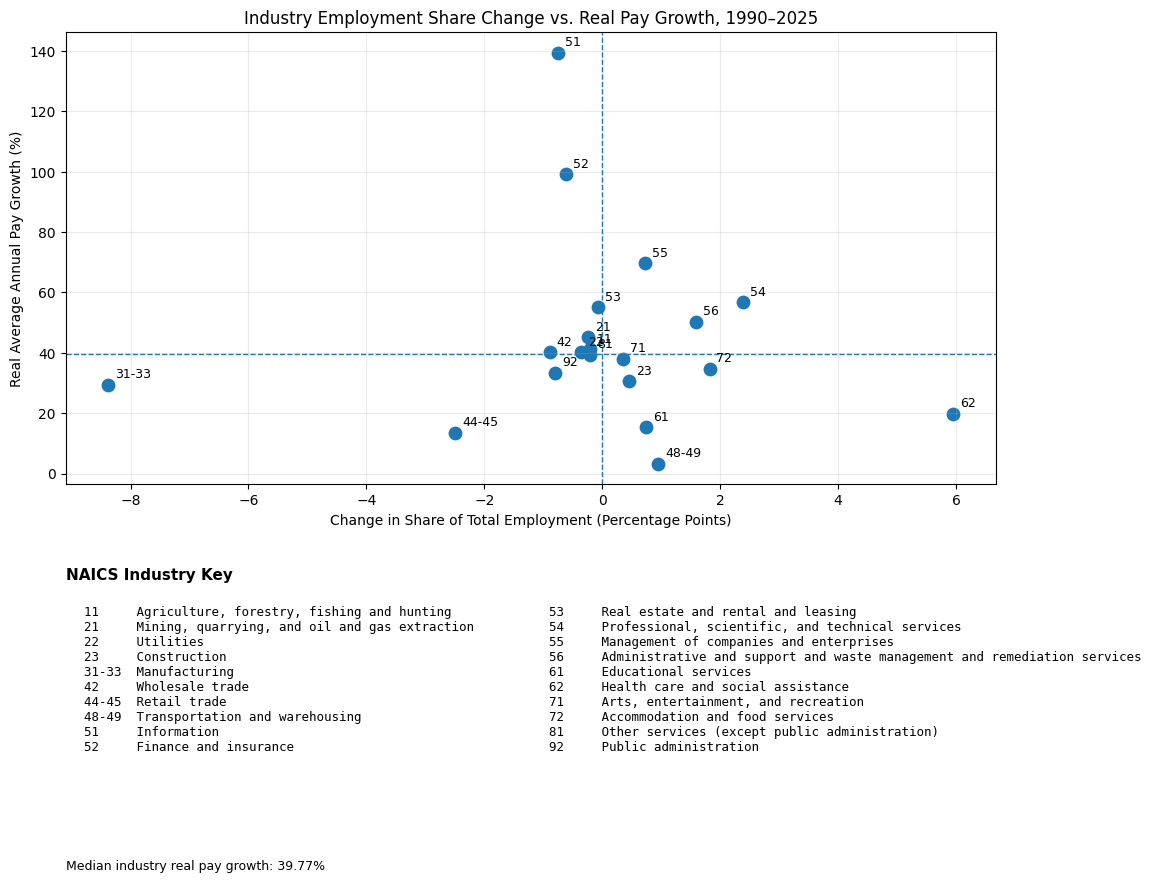

In [39]:
import matplotlib.pyplot as plt

plot_data = industry_position.copy()

# Build NAICS key
industry_key = (
    plot_data[["industry_code", "industry_title"]]
    .drop_duplicates()
    .sort_values("industry_code")
    .copy()
)

industry_key["clean_title"] = industry_key.apply(
    lambda row: row["industry_title"].replace(
        f"NAICS {row['industry_code']} ",
        ""
    ),
    axis=1
)

# Create figure with chart on top and key underneath
fig = plt.figure(figsize=(12, 11))

gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[3.2, 2.2],
    hspace=0.22
)

ax = fig.add_subplot(gs[0])
ax_key = fig.add_subplot(gs[1])

# -------------------------
# Main scatter plot
# -------------------------

ax.scatter(
    plot_data["employment_share_change_pp"],
    plot_data["real_pay_growth_pct"],
    s=80
)

for _, row in plot_data.iterrows():
    ax.annotate(
        row["industry_code"],
        (
            row["employment_share_change_pp"],
            row["real_pay_growth_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

median_real_pay = plot_data["real_pay_growth_pct"].median()

ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y=median_real_pay,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Industry Employment Share Change vs. Real Pay Growth, 1990–2025"
)

ax.set_xlabel(
    "Change in Share of Total Employment (Percentage Points)"
)

ax.set_ylabel(
    "Real Average Annual Pay Growth (%)"
)

ax.grid(alpha=0.25)

# -------------------------
# NAICS key underneath
# -------------------------

ax_key.axis("off")

ax_key.text(
    0,
    1,
    "NAICS Industry Key",
    fontsize=11,
    fontweight="bold",
    va="top"
)

key_lines = [
    f"{row['industry_code']:<6} {row['clean_title']}"
    for _, row in industry_key.iterrows()
]

# Split into two columns so the key stays compact
midpoint = (len(key_lines) + 1) // 2

left_column = "\n".join(key_lines[:midpoint])
right_column = "\n".join(key_lines[midpoint:])

ax_key.text(
    0.02,
    0.88,
    left_column,
    fontsize=9,
    family="monospace",
    va="top"
)

ax_key.text(
    0.52,
    0.88,
    right_column,
    fontsize=9,
    family="monospace",
    va="top"
)

ax_key.text(
    0,
    0.02,
    f"Median industry real pay growth: {median_real_pay:.2f}%",
    fontsize=9,
    va="bottom"
)

plt.show()

In [40]:
employment_realpay_corr = industry_position[
    ["employment_share_change_pp", "real_pay_growth_pct"]
].corr()

employment_realpay_corr

,employment_share_change_pp,real_pay_growth_pct
employment_share_change_pp,1.000000,-0.042193
real_pay_growth_pct,-0.042193,1.000000


### Employment Share Change vs. Real Pay Growth

The scatter plot compares each broad NAICS industry's **change in share of total employment** with its **CPI-adjusted growth in average annual pay** between 1990 and 2025.

The dashed vertical line at **0 percentage points** separates industries that gained employment share from industries that lost employment share. The dashed horizontal line represents the **median real-pay growth across the 20 comparable industries (39.77%)**.

A Pearson correlation was calculated to measure the linear association between employment-share change and real-pay growth:

**Pearson correlation: r = -0.042**

This coefficient is extremely close to zero, indicating **essentially no linear association between changes in an industry's share of employment and its real average-pay growth** across the broad industries examined.

Several industries illustrate this divergence:

- **Information (NAICS 51)** lost approximately **0.75 percentage points of employment share** while real average pay increased approximately **139.5%**.
- **Health Care and Social Assistance (NAICS 62)** gained approximately **5.95 percentage points of employment share**, the largest increase among the industries examined, while real average pay increased approximately **19.8%**.
- **Transportation and Warehousing (NAICS 48-49)** gained approximately **0.95 percentage points of employment share** while real average pay increased only approximately **3.3%**.
- **Manufacturing (NAICS 31-33)** lost approximately **8.38 percentage points of employment share**, the largest decline, while real average pay nevertheless increased approximately **29.4%**.

### Interpretation

At the broad-industry level, industries that gained employment share between 1990 and 2025 did not systematically experience greater growth in average worker purchasing power.

This result should **not** be interpreted as evidence that employment growth has no effect on wages. The analysis contains only 20 broad industry sectors, measures changes between two endpoints, and the Pearson correlation measures only linear association. It does not establish causation.

Instead, the result demonstrates that **employment growth and real-pay growth represent distinct dimensions of structural economic change** and should be analyzed separately.

The next analytical question is whether changes in an industry's **share of the total wage pool** show a stronger relationship with real-pay growth than changes in employment share.

In [41]:
wageshare_realpay_corr = industry_position[
    ["wage_share_change_pp", "real_pay_growth_pct"]
].corr()

wageshare_realpay_corr

,wage_share_change_pp,real_pay_growth_pct
wage_share_change_pp,1.000000,0.273755
real_pay_growth_pct,0.273755,1.000000


In [42]:
shift_realpay_corr = industry_position[
    ["wage_vs_employment_shift_pp", "real_pay_growth_pct"]
].corr()

shift_realpay_corr

,wage_vs_employment_shift_pp,real_pay_growth_pct
wage_vs_employment_shift_pp,1.000000,0.744719
real_pay_growth_pct,0.744719,1.000000


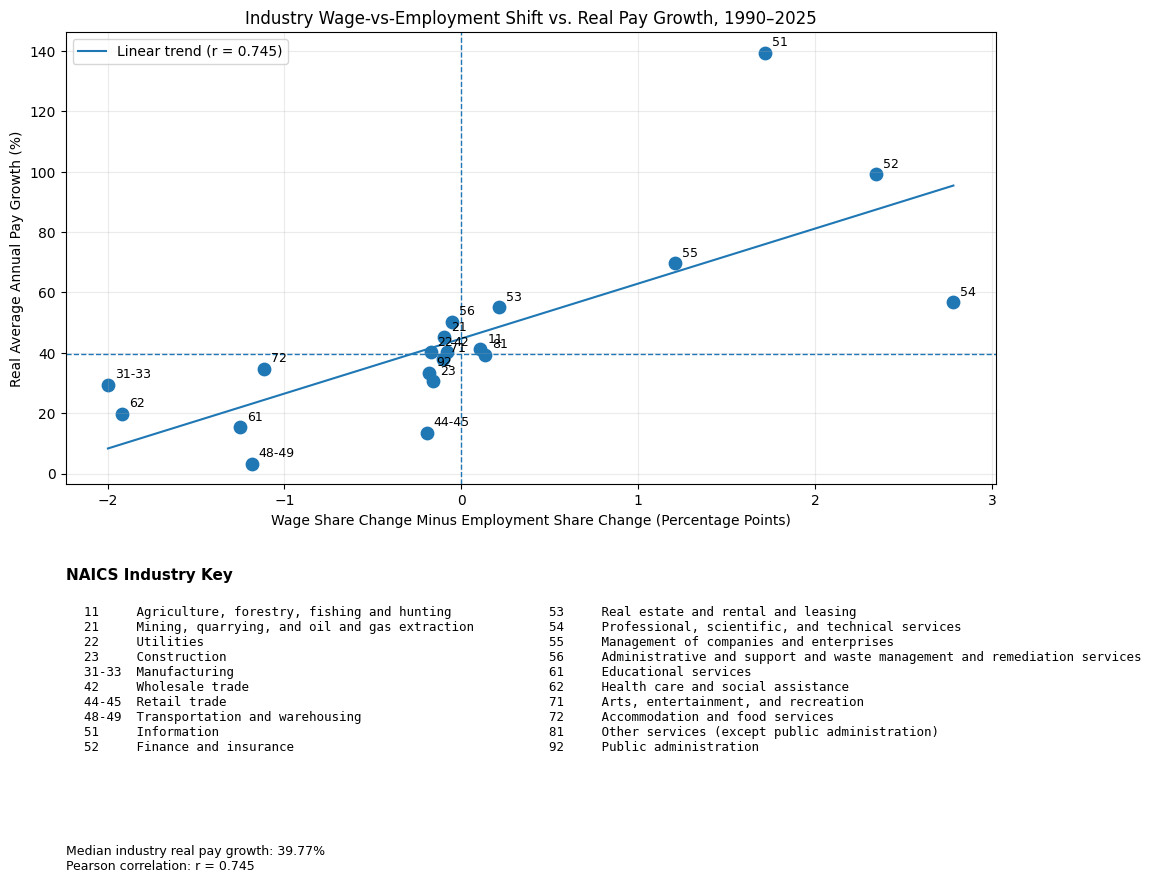

In [44]:
import matplotlib.pyplot as plt

plot_data = industry_position.copy()

# Build NAICS key
industry_key = (
    plot_data[["industry_code", "industry_title"]]
    .drop_duplicates()
    .sort_values("industry_code")
    .copy()
)

industry_key["clean_title"] = industry_key.apply(
    lambda row: row["industry_title"].replace(
        f"NAICS {row['industry_code']} ",
        ""
    ),
    axis=1
)

# Create figure with chart on top and key underneath
fig = plt.figure(figsize=(12, 11))

gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[3.2, 2.2],
    hspace=0.22
)

ax = fig.add_subplot(gs[0])
ax_key = fig.add_subplot(gs[1])

# -------------------------
# Main scatter plot
# -------------------------

ax.scatter(
    plot_data["wage_vs_employment_shift_pp"],
    plot_data["real_pay_growth_pct"],
    s=80
)

import numpy as np

# Linear trend line
x = plot_data["wage_vs_employment_shift_pp"]
y = plot_data["real_pay_growth_pct"]

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linestyle="-",
    linewidth=1.5,
    label=f"Linear trend (r = {shift_realpay_corr.iloc[0,1]:.3f})"
)

ax.legend()

# Label points with NAICS codes
for _, row in plot_data.iterrows():
    ax.annotate(
        row["industry_code"],
        (
            row["wage_vs_employment_shift_pp"],
            row["real_pay_growth_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

median_real_pay = plot_data["real_pay_growth_pct"].median()

# Reference lines
ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y=median_real_pay,
    linestyle="--",
    linewidth=1
)

# Labels and title
ax.set_title(
    "Industry Wage-vs-Employment Shift vs. Real Pay Growth, 1990–2025"
)

ax.set_xlabel(
    "Wage Share Change Minus Employment Share Change (Percentage Points)"
)

ax.set_ylabel(
    "Real Average Annual Pay Growth (%)"
)

ax.grid(alpha=0.25)

# -------------------------
# NAICS key underneath
# -------------------------

ax_key.axis("off")

ax_key.text(
    0,
    1,
    "NAICS Industry Key",
    fontsize=11,
    fontweight="bold",
    va="top"
)

key_lines = [
    f"{row['industry_code']:<6} {row['clean_title']}"
    for _, row in industry_key.iterrows()
]

midpoint = (len(key_lines) + 1) // 2

left_column = "\n".join(key_lines[:midpoint])
right_column = "\n".join(key_lines[midpoint:])

ax_key.text(
    0.02,
    0.88,
    left_column,
    fontsize=9,
    family="monospace",
    va="top"
)

ax_key.text(
    0.52,
    0.88,
    right_column,
    fontsize=9,
    family="monospace",
    va="top"
)

ax_key.text(
    0,
    0.02,
    f"Median industry real pay growth: {median_real_pay:.2f}%\n"
    f"Pearson correlation: r = 0.745",
    fontsize=9,
    va="bottom"
)

plt.show()

### Industry Structural Change and Real Pay Growth: Correlation Summary

To evaluate how changes in the structure of U.S. employment and wages relate to changes in worker purchasing power, three industry-level measures were compared with **CPI-adjusted growth in average annual pay from 1990 to 2025**.

The analysis includes **20 comparable broad NAICS industries** and uses the Pearson correlation coefficient to measure linear association.

| Industry Measure | Correlation with Real Pay Growth | Interpretation |
|---|---:|---|
| Employment Share Change | **r = -0.042** | Essentially no linear association |
| Wage Share Change | **r = +0.274** | Weak positive association |
| Wage-vs-Employment Shift | **r = +0.745** | Strong positive association |

#### Employment Share Change

The correlation between **employment-share change** and **real average-pay growth** is approximately **-0.042**, indicating essentially no linear association.

Industries that gained a larger share of total employment did not systematically experience greater real-pay growth. Likewise, industries that lost employment share did not necessarily experience weak real-pay growth.

This indicates that changes in where U.S. employment was concentrated and changes in average worker purchasing power were largely separate dimensions of industry-level economic change over this period.

#### Wage Share Change

The correlation between **wage-share change** and **real average-pay growth** is approximately **+0.274**.

This represents a weak positive association. Industries that gained a greater share of the total wage pool tended, on average, to experience somewhat stronger real-pay growth, although the relationship is not particularly strong.

#### Wage-vs-Employment Shift

The strongest relationship appears when comparing real-pay growth with the **wage-vs-employment shift**, defined as:

**Wage-vs-Employment Shift = Change in Wage Share - Change in Employment Share**

A positive value indicates that an industry's share of total wages improved relative to the change in its share of total employment.

A negative value indicates that the industry's wage share underperformed relative to the change in its employment share.

The correlation between this measure and real-pay growth is approximately:

**r = +0.745**

This represents a strong positive linear association across the industries examined.

Industries whose wage share improved relative to their employment share generally experienced greater growth in CPI-adjusted average annual pay. Conversely, industries whose employment share grew faster than their wage share generally experienced weaker real-pay growth.

The scatter plot illustrates this relationship through a clear upward linear trend. Industries such as **Information (NAICS 51)** and **Finance and Insurance (NAICS 52)** experienced positive wage-vs-employment shifts alongside substantial real-pay growth. Industries such as **Health Care and Social Assistance (NAICS 62)** and **Transportation and Warehousing (NAICS 48-49)** experienced negative wage-vs-employment shifts and comparatively weaker real-pay growth.

### Interpretation and Limitations

These results are descriptive and should not be interpreted as evidence of causation.

In particular, wage share, employment share, and average pay are **mechanically related economic measures**. Total industry wages are influenced by both employment and compensation, meaning the strong relationship between wage-vs-employment shift and average-pay growth is not an independent causal relationship.

The analysis also compares two endpoints, **1990 and 2025**, across only 20 broad industry sectors. Pearson correlation measures linear association and does not capture all possible relationships between these variables.

The results therefore support a narrower conclusion:

> **At the broad-industry level, changes in employment share between 1990 and 2025 had essentially no linear association with real average-pay growth. Changes in wage share showed a modest positive association, while industries whose wage share increasingly outperformed their employment share tended to experience substantially stronger real-pay growth.**

This establishes an important distinction between **where employment moved**, **where wages moved**, and **where worker purchasing power improved**.

The next stage of the analysis will move beyond the 1990 and 2025 endpoints and examine how these measures evolved through time.

### QCEW Sector Aggregation — Analytical Reference Note

The `sector_distribution` dataframe is the validated annual national-sector analytical panel and should be reused for subsequent 1990–2025 industry analysis.

**Construction**

Sector observations are restricted BEFORE aggregation to:

- `geography_level = 'National'`
- `industry_detail_level = 'NAICS Sector (2-digit)'`
- `own_code IN (1, 2, 3, 5)` — Federal, State, Local, and Private ownership

`annual_avg_emplvl` and `total_annual_wages` are then summed across these ownership components for each:

**Year × National × NAICS Sector**

This does **not** sum across different NAICS hierarchy levels and therefore avoids double-counting parent and child industry observations.

**National Denominator**

Employment and wage shares use the published QCEW national aggregate rather than reconstructing the national total by summing industries:

- `geography_level = 'National'`
- `industry_detail_level = 'All industries / aggregate total'`
- `own_code = 0` — Total Covered

Therefore:

**Employment Share = Sector Employment / Published National Employment**

**Wage Share = Sector Wages / Published National Wages**

**Important Rule**

Do NOT perform unrestricted sums of QCEW employment or wages across the full analytical/visualization dataset. QCEW contains overlapping geographic, ownership, and industry hierarchy observations.

Always select the intended observation grain first, then aggregate only dimensions known to be additive.

**Current Analytical Status**

`sector_distribution` already contains the annual 1990–2025 sector observations. The 1990→2025 endpoint analysis was created by selecting those two years from this existing annual panel. The endpoint analysis therefore does not need to be rebuilt.

In [45]:
# Validate the annual sector_distribution panel

print("=== SECTOR DISTRIBUTION VALIDATION ===\n")

print("Rows:", len(sector_distribution))
print(
    "Year range:",
    sector_distribution["year"].min(),
    "to",
    sector_distribution["year"].max()
)
print(
    "Unique industries:",
    sector_distribution["industry_code"].nunique()
)

print("\nIndustries per year:")
display(
    sector_distribution
    .groupby("year")["industry_code"]
    .nunique()
    .reset_index(name="industry_count")
)

# Check for duplicate Year × Industry observations
duplicates = (
    sector_distribution
    .groupby(["year", "industry_code"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
)

print("\nDuplicate Year × Industry observations:", len(duplicates))

if len(duplicates) > 0:
    display(duplicates)

# Check NULLs
print("\nNULL counts:")
display(
    sector_distribution[
        [
            "year",
            "industry_code",
            "industry_title",
            "sector_employment",
            "sector_wages",
            "employment_share_pct",
            "wage_share_pct"
        ]
    ].isna().sum()
)

# Inspect annual share totals
annual_share_check = (
    sector_distribution
    .groupby("year", as_index=False)
    .agg(
        summed_employment_share=("employment_share_pct", "sum"),
        summed_wage_share=("wage_share_pct", "sum"),
        sector_count=("industry_code", "nunique")
    )
)

display(annual_share_check)

=== SECTOR DISTRIBUTION VALIDATION ===

Rows: 745
Year range: 1990 to 2025
Unique industries: 21

Industries per year:


,year,industry_count
0,1990,20
1,1991,20
2,1992,20
3,1993,20
4,1994,20
5,1995,20
6,1996,20
7,1997,20
8,1998,20
9,1999,20



Duplicate Year × Industry observations: 0

NULL counts:


year                    0
industry_code           0
industry_title          0
sector_employment       0
sector_wages            0
employment_share_pct    0
wage_share_pct          0
dtype: int64

,year,summed_employment_share,summed_wage_share,sector_count
0,1990,99.920314,99.932924,20
1,1991,99.925467,99.932053,20
2,1992,99.924079,99.930557,20
3,1993,99.919674,99.927989,20
4,1994,99.921199,99.930593,20
5,1995,99.915760,99.926793,20
6,1996,99.909423,99.912921,20
7,1997,99.904261,99.916991,20
8,1998,99.885433,99.893544,20
9,1999,99.847487,99.852861,20


### Validation Note — QCEW Published Totals and Component Differences

Annual sector employment and wage shares reconcile to approximately 100% of the published BLS QCEW national totals across the 1990–2025 analytical period.

Small differences from exactly 100% are expected and are consistent with previously documented differences between the published BLS **Total Covered** observations and totals reconstructed from the underlying Federal, State, Local, and Private ownership components. These differences are particularly visible in earlier historical releases and reflect characteristics of the published source data rather than an error introduced by the AEDR analytical calculations.

The observed differences are very small relative to total national employment and wages and are not expected to have a meaningful effect on the distributional findings of this research.

Accordingly, the published BLS national Total Covered observations remain the denominator for employment-share and wage-share calculations, while sector totals are constructed from the applicable ownership components.

**Analytical treatment:** Retain the source data as published, document the discrepancy, and proceed without adjustment.

In [46]:
# Identify the change in sector coverage between 2000 and 2001

codes_2000 = set(
    sector_distribution.loc[
        sector_distribution["year"] == 2000,
        "industry_code"
    ]
)

codes_2001 = set(
    sector_distribution.loc[
        sector_distribution["year"] == 2001,
        "industry_code"
    ]
)

added_2001 = codes_2001 - codes_2000
removed_2001 = codes_2000 - codes_2001

print("Added in 2001:", added_2001)
print("Removed in 2001:", removed_2001)

sector_distribution[
    (sector_distribution["year"].isin([2000, 2001])) &
    (sector_distribution["industry_code"].isin(added_2001 | removed_2001))
][
    [
        "year",
        "industry_code",
        "industry_title",
        "sector_employment",
        "sector_wages",
        "employment_share_pct",
        "wage_share_pct"
    ]
]

Added in 2001: {'99'}
Removed in 2001: set()


,year,industry_code,industry_title,sector_employment,sector_wages,employment_share_pct,wage_share_pct
240,2001,99,NAICS 99 Unclassified,254603.0,9.399083e+09,0.196399,0.200184


### Sector Coverage Note — NAICS 99 Unclassified

Annual QCEW sector coverage contains 20 reported NAICS sectors from 1990–2000 and 21 sectors from 2001–2025.

Validation confirmed that the sole change in sector count is the appearance of **NAICS 99 — Unclassified** beginning in 2001. No previously reported sector was removed.

The appearance of NAICS 99 should be interpreted as a change in industry classification rather than the creation of a new economic sector. Employment and wages assigned to the Unclassified category were already represented within national QCEW totals; beginning in 2001, a small portion of that activity was reported separately as Unclassified.

In its first observed year, NAICS 99 represented approximately **0.20% of national employment and 0.20% of national wages**. Because this share is very small relative to the much larger long-run changes observed across major sectors, the classification change is not expected to have a meaningful effect on the primary distributional findings of the analysis.

Because NAICS 99 has no corresponding observation for 1990, it is excluded naturally from analyses requiring a common 1990 baseline, including the 1990→2025 sector comparison. It remains preserved in annual analyses beginning in 2001 and may be analyzed separately using 2001 as its first observed baseline where appropriate.

No imputation, retrospective redistribution, or historical backfilling is performed. The analysis preserves the historical BLS classifications as published and treats the introduction of NAICS 99 as a documented methodological limitation.

In [52]:
# Build annual sector panel with CPI-adjusted average pay

sector_annual_real = sector_distribution.merge(
    annual_cpi_analysis[
        ["year", "annual_avg_cpi", "months_present"]
    ],
    on="year",
    how="left",
    validate="many_to_one"
)

# Calculate nominal average annual pay at the sector level
sector_annual_real["avg_annual_pay"] = (
    sector_annual_real["sector_wages"]
    / sector_annual_real["sector_employment"]
)

# Use 2025 as the constant-dollar reference year
cpi_2025 = annual_cpi_analysis.loc[
    annual_cpi_analysis["year"].eq(2025),
    "annual_avg_cpi"
].iloc[0]

# Convert each year's average annual pay into 2025 dollars
sector_annual_real["real_avg_annual_pay_2025_dollars"] = (
    sector_annual_real["avg_annual_pay"]
    * (cpi_2025 / sector_annual_real["annual_avg_cpi"])
)

# Basic validation
print("Rows:", len(sector_annual_real))
print(
    "Years:",
    sector_annual_real["year"].min(),
    "to",
    sector_annual_real["year"].max()
)
print(
    "Missing CPI:",
    sector_annual_real["annual_avg_cpi"].isna().sum()
)
print(
    "Missing real pay:",
    sector_annual_real["real_avg_annual_pay_2025_dollars"].isna().sum()
)

sector_annual_real[
    sector_annual_real["year"].isin([1990, 2025])
][
    [
        "year",
        "industry_code",
        "industry_title",
        "sector_employment",
        "sector_wages",
        "avg_annual_pay",
        "annual_avg_cpi",
        "real_avg_annual_pay_2025_dollars",
        "employment_share_pct",
        "wage_share_pct"
    ]
].head(10)

Rows: 745
Years: 1990 to 2025
Missing CPI: 0
Missing real pay: 0


,year,industry_code,industry_title,sector_employment,sector_wages,avg_annual_pay,annual_avg_cpi,real_avg_annual_pay_2025_dollars,employment_share_pct,wage_share_pct
0,1990,11,"NAICS 11 Agriculture, forestry, fishing and hu...",1093997.0,1.539464e+10,14071.919400,130.658333,34699.498486,1.007331,0.600515
1,1990,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",662721.0,2.472192e+10,37303.667732,130.658333,91985.927804,0.610220,0.964354
2,1990,22,NAICS 22 Utilities,999374.0,3.717004e+10,37193.325903,130.658333,91713.839397,0.920204,1.449930
3,1990,23,NAICS 23 Construction,5386716.0,1.413970e+11,26249.207092,130.658333,64727.084902,4.959981,5.515620
4,1990,31-33,NAICS 31-33 Manufacturing,17913919.0,5.026576e+11,28059.609612,130.658333,69191.298895,16.494780,19.607683
5,1990,42,NAICS 42 Wholesale trade,5177587.0,1.585874e+11,30629.591394,130.658333,75528.535234,4.767419,6.186181
6,1990,44-45,NAICS 44-45 Retail trade,13484035.0,2.093570e+11,15526.285565,130.658333,38285.773756,12.415831,8.166604
7,1990,48-49,NAICS 48-49 Transportation and warehousing,4263742.0,1.172797e+11,27506.294282,130.658333,67826.896223,3.925969,4.574852
8,1990,51,NAICS 51 Information,2900381.0,9.048071e+10,31196.147573,130.658333,76925.588096,2.670613,3.529475
9,1990,52,NAICS 52 Finance and insurance,5106315.0,1.589477e+11,31127.671349,130.658333,76756.734754,4.701793,6.200237


In [53]:
# Validate annual real-pay panel against previously validated endpoint analysis

endpoint_check = (
    sector_annual_real[
        sector_annual_real["year"].isin([1990, 2025])
    ]
    .pivot(
        index=["industry_code", "industry_title"],
        columns="year",
        values=["avg_annual_pay", "real_avg_annual_pay_2025_dollars"]
    )
)

endpoint_check.columns = [
    f"{measure}_{year}"
    for measure, year in endpoint_check.columns
]

endpoint_check = endpoint_check.reset_index()

# Compare against the previously validated endpoint table
endpoint_validation = endpoint_check.merge(
    real_pay_comparison[
        [
            "industry_code",
            "industry_title",
            "avg_annual_pay_1990",
            "1990_pay_in_2025_dollars",
            "avg_annual_pay_2025"
        ]
    ],
    on=["industry_code", "industry_title"],
    how="inner",
    validate="one_to_one"
)

endpoint_validation["diff_nominal_1990"] = (
    endpoint_validation["avg_annual_pay_1990_x"]
    - endpoint_validation["avg_annual_pay_1990_y"]
)

endpoint_validation["diff_real_1990"] = (
    endpoint_validation["real_avg_annual_pay_2025_dollars_1990"]
    - endpoint_validation["1990_pay_in_2025_dollars"]
)

endpoint_validation["diff_nominal_2025"] = (
    endpoint_validation["avg_annual_pay_2025_x"]
    - endpoint_validation["avg_annual_pay_2025_y"]
)

print("Industries compared:", len(endpoint_validation))

print(
    "Max absolute 1990 nominal difference:",
    endpoint_validation["diff_nominal_1990"].abs().max()
)

print(
    "Max absolute 1990 real difference:",
    endpoint_validation["diff_real_1990"].abs().max()
)

print(
    "Max absolute 2025 nominal difference:",
    endpoint_validation["diff_nominal_2025"].abs().max()
)

endpoint_validation[
    [
        "industry_code",
        "industry_title",
        "diff_nominal_1990",
        "diff_real_1990",
        "diff_nominal_2025"
    ]
]

Industries compared: 21
Max absolute 1990 nominal difference: 0.0
Max absolute 1990 real difference: 0.0
Max absolute 2025 nominal difference: 0.0


,industry_code,industry_title,diff_nominal_1990,diff_real_1990,diff_nominal_2025
0,11,"NAICS 11 Agriculture, forestry, fishing and hu...",0.0,0.0,0.0
1,21,"NAICS 21 Mining, quarrying, and oil and gas ex...",0.0,0.0,0.0
2,22,NAICS 22 Utilities,0.0,0.0,0.0
3,23,NAICS 23 Construction,0.0,0.0,0.0
4,31-33,NAICS 31-33 Manufacturing,0.0,0.0,0.0
5,42,NAICS 42 Wholesale trade,0.0,0.0,0.0
6,44-45,NAICS 44-45 Retail trade,0.0,0.0,0.0
7,48-49,NAICS 48-49 Transportation and warehousing,0.0,0.0,0.0
8,51,NAICS 51 Information,0.0,0.0,0.0
9,52,NAICS 52 Finance and insurance,0.0,0.0,0.0


### Annual Sector Real-Pay Panel — Validation

The annual sector-level analytical panel (`sector_annual_real`) combines the validated QCEW national sector distribution with the corrected annual CPI series for 1990–2025.

For each Year × NAICS Sector observation:

- Nominal average annual pay is calculated as total sector annual wages divided by sector annual average employment.
- Historical nominal pay is converted to constant 2025 dollars using the annual CPI-U.
- Employment share and wage share are retained from the validated `sector_distribution` panel.

The resulting panel contains **745 observations spanning 1990–2025**, with no missing CPI values and no missing real-pay values for reported sector observations.

As an independent consistency check, the annual panel's 1990 and 2025 values were reconciled against the previously validated 1990→2025 endpoint analysis. Maximum differences were:

- **1990 nominal average annual pay: 0.0**
- **1990 real average annual pay (2025 dollars): 0.0**
- **2025 nominal average annual pay: 0.0**

The annual panel therefore reproduces the previously validated endpoint calculations exactly.

Twenty sectors contain complete 1990→2025 observations. **NAICS 99 — Unclassified** is additionally present beginning in 2001 and therefore has no 1990 comparison value; it remains preserved in the annual panel according to the previously documented baseline treatment.

**Validation status:** PASSED — `sector_annual_real` is approved for annual trajectory and distributional analysis.

In [55]:
# Calculate annual changes in employment share

sector_annual_real = sector_annual_real.sort_values(
    ["industry_code", "year"]
).copy()

sector_annual_real["employment_share_change_yoy_pp"] = (
    sector_annual_real
    .groupby("industry_code")["employment_share_pct"]
    .diff()
)

# Largest absolute one-year employment-share movement for each industry
employment_shift_peaks = (
    sector_annual_real
    .dropna(subset=["employment_share_change_yoy_pp"])
    .assign(
        abs_change=lambda x:
            x["employment_share_change_yoy_pp"].abs()
    )
    .sort_values("abs_change", ascending=False)
    .groupby("industry_code", as_index=False)
    .first()
    .sort_values("abs_change", ascending=False)
)

employment_shift_peaks[
    [
        "industry_code",
        "industry_title",
        "year",
        "employment_share_change_yoy_pp",
        "employment_share_pct"
    ]
]

,industry_code,industry_title,year,employment_share_change_yoy_pp,employment_share_pct
17,72,NAICS 72 Accommodation and food services,2020,-1.523744,8.030213
15,62,NAICS 62 Health care and social assistance,2009,0.880846,13.813296
4,31-33,NAICS 31-33 Manufacturing,2002,-0.778186,11.901924
3,23,NAICS 23 Construction,2009,-0.655068,4.771407
14,61,NAICS 61 Educational services,2009,0.486197,9.464311
16,71,"NAICS 71 Arts, entertainment, and recreation",2020,-0.431116,1.451510
13,56,NAICS 56 Administrative and support and waste ...,2009,-0.364001,5.629205
11,54,"NAICS 54 Professional, scientific, and technic...",2020,0.362256,6.879542
18,81,NAICS 81 Other services (except public adminis...,2013,-0.356861,3.126725
6,44-45,NAICS 44-45 Retail trade,2022,-0.354975,10.356637


### Largest Annual Employment-Share Movement by Industry

To identify periods of significant change in the distribution of U.S. employment, the year-over-year change in each industry's share of total national covered employment was calculated for every available year.

For each industry:

**Annual Employment-Share Change = Current-Year Employment Share − Prior-Year Employment Share**

The absolute value of each annual change was then used to identify the **single largest one-year employment-share movement for each industry** over the 1990–2025 analytical period.

Each industry therefore appears **once** in the resulting table. The selected observation may represent either an increase or a decrease depending on which annual movement was largest in absolute magnitude.

The columns should be interpreted as follows:

- **`industry_code`** — NAICS sector identifier.
- **`industry_title`** — NAICS sector name.
- **`year`** — Ending year of the industry's largest annual movement (for example, 2020 represents the change from 2019→2020).
- **`employment_share_change_yoy_pp`** — Change in the industry's share of national covered employment from the previous year, measured in percentage points.
- **`employment_share_pct`** — The industry's actual share of national covered employment in the ending year.

A positive change indicates that the industry accounted for a larger share of national employment than in the preceding year. A negative change indicates that its employment share declined.

Importantly, employment-share movement does **not necessarily represent absolute job creation or job loss**. An industry's share can increase because its employment grew, because employment elsewhere declined more rapidly, or through a combination of both.

This measure is therefore used to identify **when the distribution of employment across industries shifted most sharply**, rather than to establish the cause of those shifts.

In [56]:
# Measure total year-to-year redistribution of employment shares

annual_employment_redistribution = (
    sector_annual_real
    .dropna(subset=["employment_share_change_yoy_pp"])
    .groupby("year", as_index=False)
    .agg(
        total_absolute_share_movement_pp=(
            "employment_share_change_yoy_pp",
            lambda x: x.abs().sum()
        )
    )
)

# Divide by 2 because gains and losses are two sides
# of the same redistribution
annual_employment_redistribution[
    "employment_redistribution_pp"
] = (
    annual_employment_redistribution[
        "total_absolute_share_movement_pp"
    ] / 2
)

annual_employment_redistribution.sort_values(
    "employment_redistribution_pp",
    ascending=False
).head(15)

,year,total_absolute_share_movement_pp,employment_redistribution_pp
29,2020,4.765183,2.382592
18,2009,4.146223,2.073111
0,1991,2.633983,1.316992
11,2002,2.576040,1.288020
31,2022,2.411539,1.205769
30,2021,2.319349,1.159675
17,2008,2.196221,1.098111
10,2001,2.166116,1.083058
1,1992,1.830271,0.915136
33,2024,1.714765,0.857382


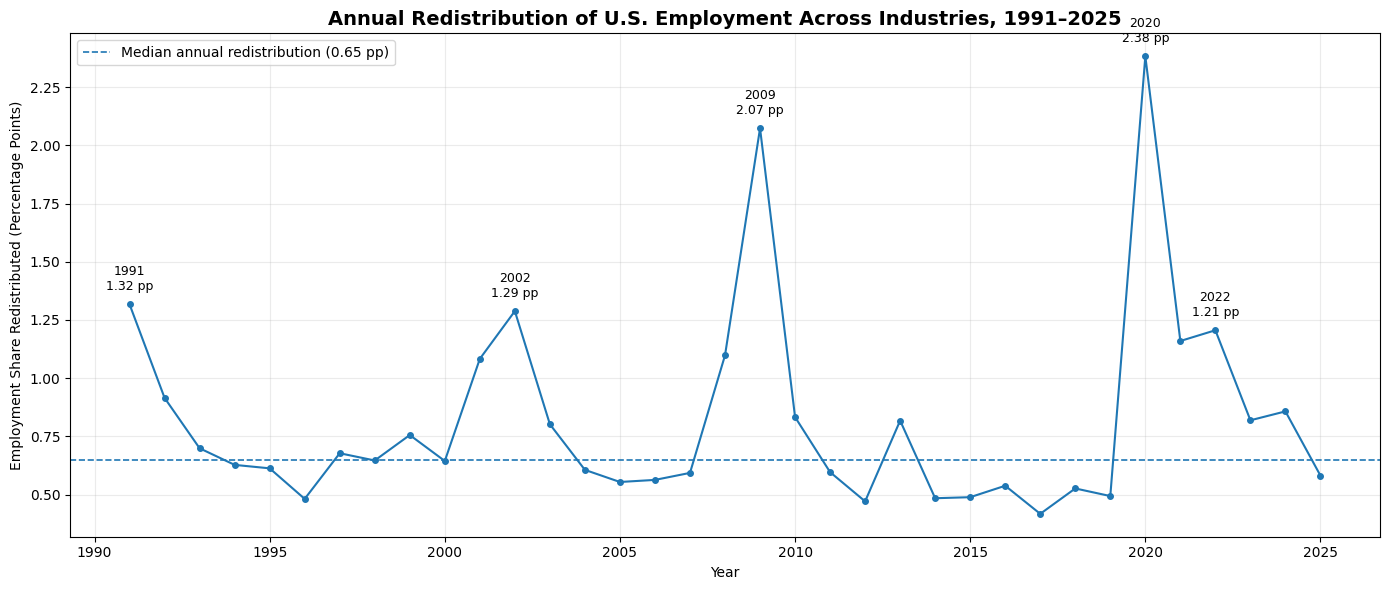

In [57]:
import matplotlib.pyplot as plt

# Sort chronologically for plotting
redistribution_plot = (
    annual_employment_redistribution
    .sort_values("year")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 6))

# Annual employment redistribution
ax.plot(
    redistribution_plot["year"],
    redistribution_plot["employment_redistribution_pp"],
    marker="o",
    markersize=4,
    linewidth=1.5
)

# Reference line: median annual redistribution
median_redistribution = (
    redistribution_plot["employment_redistribution_pp"].median()
)

ax.axhline(
    median_redistribution,
    linestyle="--",
    linewidth=1.2,
    label=f"Median annual redistribution ({median_redistribution:.2f} pp)"
)

# Label the five largest redistribution years
top_5 = redistribution_plot.nlargest(
    5,
    "employment_redistribution_pp"
)

for _, row in top_5.iterrows():
    ax.annotate(
        f'{int(row["year"])}\n{row["employment_redistribution_pp"]:.2f} pp',
        (
            row["year"],
            row["employment_redistribution_pp"]
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Annual Redistribution of U.S. Employment Across Industries, 1991–2025",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Employment Share Redistributed (Percentage Points)")

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Annual Employment Redistribution — Interpretation

Annual employment redistribution measures the year-to-year movement in the distribution of national covered employment across broad NAICS sectors.

For each year, the absolute changes in sector employment shares are summed and divided by two so that corresponding gains and losses are not double-counted. The resulting measure represents the percentage-point share of national employment redistributed among sectors relative to the preceding year.

Across 1991–2025, the median annual redistribution was approximately **0.65 percentage points**. Most years remained relatively close to this level, while several periods experienced substantially larger changes.

The largest observed annual redistributions were:

- **2020: 2.38 percentage points**
- **2009: 2.07 percentage points**
- **1991: 1.32 percentage points**
- **2002: 1.29 percentage points**
- **2022: 1.21 percentage points**

The annual series also shows periods of elevated redistribution rather than uniformly distributed change across the full 1990–2025 period.

These results are descriptive. They identify **when and to what extent the industry distribution of employment changed**, but do not independently establish the causes of those changes. The previously documented introduction of **NAICS 99 — Unclassified** beginning in 2001 should also be considered when interpreting redistribution around that classification transition.

In [58]:
# Calculate annual changes in wage share

sector_annual_real["wage_share_change_yoy_pp"] = (
    sector_annual_real
    .groupby("industry_code")["wage_share_pct"]
    .diff()
)

# Largest absolute one-year wage-share movement for each industry
wage_shift_peaks = (
    sector_annual_real
    .dropna(subset=["wage_share_change_yoy_pp"])
    .assign(
        abs_change=lambda x:
            x["wage_share_change_yoy_pp"].abs()
    )
    .sort_values("abs_change", ascending=False)
    .groupby("industry_code", as_index=False)
    .first()
    .sort_values("abs_change", ascending=False)
)

wage_shift_peaks[
    [
        "industry_code",
        "industry_title",
        "year",
        "wage_share_change_yoy_pp",
        "wage_share_pct"
    ]
]

,industry_code,industry_title,year,wage_share_change_yoy_pp,wage_share_pct
11,54,"NAICS 54 Professional, scientific, and technic...",1995,1.694496,8.673186
9,52,NAICS 52 Finance and insurance,1997,1.575287,8.228329
4,31-33,NAICS 31-33 Manufacturing,2001,-1.211500,15.053354
15,62,NAICS 62 Health care and social assistance,2009,1.165446,13.289735
17,72,NAICS 72 Accommodation and food services,2020,-0.774459,2.874664
3,23,NAICS 23 Construction,2009,-0.670474,5.150362
14,61,NAICS 61 Educational services,2009,0.605481,8.787983
19,92,NAICS 92 Public administration,2009,0.499971,6.880934
12,55,NAICS 55 Management of companies and enterprises,1991,0.398090,1.989509
8,51,NAICS 51 Information,2002,-0.374410,4.077350


In [59]:
# Measure total year-to-year redistribution of wage shares

annual_wage_redistribution = (
    sector_annual_real
    .dropna(subset=["wage_share_change_yoy_pp"])
    .groupby("year", as_index=False)
    .agg(
        total_absolute_wage_share_movement_pp=(
            "wage_share_change_yoy_pp",
            lambda x: x.abs().sum()
        )
    )
)

# Divide by 2 because wage-share gains and losses
# are two sides of the same redistribution
annual_wage_redistribution[
    "wage_redistribution_pp"
] = (
    annual_wage_redistribution[
        "total_absolute_wage_share_movement_pp"
    ] / 2
)

annual_wage_redistribution.sort_values(
    "wage_redistribution_pp",
    ascending=False
).head(15)

,year,total_absolute_wage_share_movement_pp,wage_redistribution_pp
18,2009,5.151384,2.575692
6,1997,3.976645,1.988323
4,1995,3.834214,1.917107
11,2002,3.566943,1.783471
29,2020,3.562443,1.781221
10,2001,3.540317,1.770158
7,1998,3.448585,1.724292
0,1991,3.242310,1.621155
30,2021,3.181785,1.590893
17,2008,3.025938,1.512969


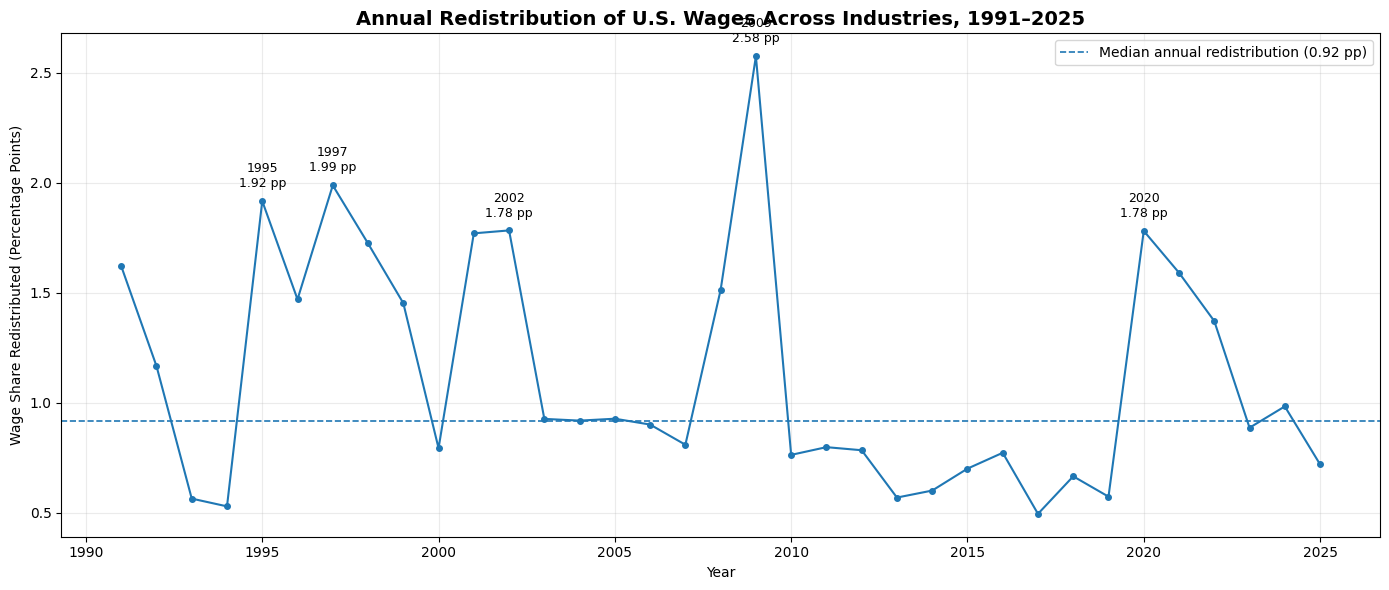

In [60]:
# Plot annual wage redistribution

wage_redistribution_plot = (
    annual_wage_redistribution
    .sort_values("year")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    wage_redistribution_plot["year"],
    wage_redistribution_plot["wage_redistribution_pp"],
    marker="o",
    markersize=4,
    linewidth=1.5
)

# Median annual wage redistribution
median_wage_redistribution = (
    wage_redistribution_plot["wage_redistribution_pp"].median()
)

ax.axhline(
    median_wage_redistribution,
    linestyle="--",
    linewidth=1.2,
    label=f"Median annual redistribution ({median_wage_redistribution:.2f} pp)"
)

# Label five largest years
top_5_wage = wage_redistribution_plot.nlargest(
    5,
    "wage_redistribution_pp"
)

for _, row in top_5_wage.iterrows():
    ax.annotate(
        f'{int(row["year"])}\n{row["wage_redistribution_pp"]:.2f} pp',
        (
            row["year"],
            row["wage_redistribution_pp"]
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Annual Redistribution of U.S. Wages Across Industries, 1991–2025",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Wage Share Redistributed (Percentage Points)")

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Annual Wage Redistribution Across Industries — Interpretation

Annual wage redistribution measures the year-to-year movement in the distribution of **total national wages across broad NAICS sectors**.

For each year, the change in every industry's share of total national wages is calculated relative to the preceding year:

**Annual Wage-Share Change = Current-Year Wage Share − Prior-Year Wage Share**

Because increases in one industry's wage share are accompanied by decreases elsewhere in the national wage distribution, the absolute values of all industry wage-share changes are summed and divided by two:

**Annual Wage Redistribution = Σ |Industry Wage-Share Changes| ÷ 2**

Dividing by two does **not** calculate an average. It prevents the same redistribution from being counted twice — once as wage share lost by one or more industries and again as wage share gained elsewhere.

The resulting measure therefore represents the magnitude of the annual **redistribution, or distributional volatility, of the national wage pool across industries**.

Across 1991–2025, median annual wage redistribution was approximately **0.92 percentage points**.

The five largest annual wage redistributions were:

- **2009: 2.58 percentage points**
- **1997: 1.99 percentage points**
- **1995: 1.92 percentage points**
- **2002: 1.78 percentage points**
- **2020: 1.78 percentage points**

Higher values indicate years in which the industry's shares of the national wage pool changed substantially relative to the preceding year. Lower values indicate a comparatively stable distribution of wages across industries.

Importantly, wage redistribution does **not** measure the total amount of wages added to or removed from the economy. Total wages may increase while redistribution remains low if industries maintain similar shares of the national wage pool.

Likewise, an increase in an industry's wage share does not establish that money literally moved from another industry into that industry. The measure identifies changes in the **relative concentration of total wages across industries**.

These results are descriptive and identify **when and to what extent the distribution of wages across industries changed**. They do not independently establish the causes of those changes.

In [61]:
# Compare annual wage redistribution with employment redistribution

redistribution_comparison = (
    annual_employment_redistribution[
        ["year", "employment_redistribution_pp"]
    ]
    .merge(
        annual_wage_redistribution[
            ["year", "wage_redistribution_pp"]
        ],
        on="year",
        how="inner",
        validate="one_to_one"
    )
)

redistribution_comparison["wage_vs_employment_gap_pp"] = (
    redistribution_comparison["wage_redistribution_pp"]
    - redistribution_comparison["employment_redistribution_pp"]
)

redistribution_comparison["absolute_gap_pp"] = (
    redistribution_comparison["wage_vs_employment_gap_pp"].abs()
)

redistribution_comparison.sort_values(
    "absolute_gap_pp",
    ascending=False
).head(15)

,year,employment_redistribution_pp,wage_redistribution_pp,wage_vs_employment_gap_pp,absolute_gap_pp
6,1997,0.677662,1.988323,1.310661,1.310661
4,1995,0.612816,1.917107,1.304291,1.304291
7,1998,0.646499,1.724292,1.077793,1.077793
5,1996,0.481621,1.470043,0.988422,0.988422
8,1999,0.755809,1.452703,0.696894,0.696894
10,2001,1.083058,1.770158,0.687100,0.687100
29,2020,2.382592,1.781221,-0.601370,0.601370
18,2009,2.073111,2.575692,0.502581,0.502581
11,2002,1.288020,1.783471,0.495452,0.495452
30,2021,1.159675,1.590893,0.431218,0.431218


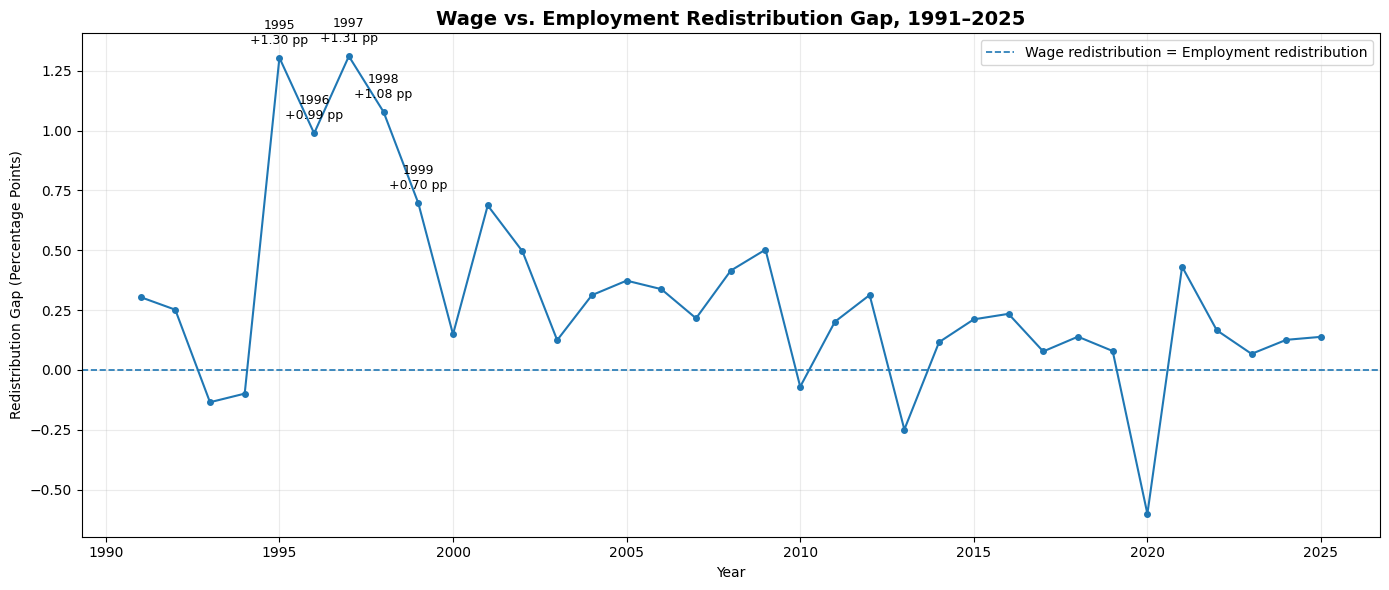

In [62]:
# Plot annual wage vs. employment redistribution gap

gap_plot = (
    redistribution_comparison
    .sort_values("year")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    gap_plot["year"],
    gap_plot["wage_vs_employment_gap_pp"],
    marker="o",
    markersize=4,
    linewidth=1.5
)

# Zero line = wage and employment redistribution were equal
ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    label="Wage redistribution = Employment redistribution"
)

# Label the five largest absolute divergences
top_5_gap = gap_plot.nlargest(
    5,
    "absolute_gap_pp"
)

for _, row in top_5_gap.iterrows():
    ax.annotate(
        f'{int(row["year"])}\n{row["wage_vs_employment_gap_pp"]:+.2f} pp',
        (
            row["year"],
            row["wage_vs_employment_gap_pp"]
        ),
        xytext=(0, 10 if row["wage_vs_employment_gap_pp"] >= 0 else -25),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Wage vs. Employment Redistribution Gap, 1991–2025",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Redistribution Gap (Percentage Points)")

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Wage vs. Employment Redistribution Gap — Interpretation

The Wage vs. Employment Redistribution Gap compares the annual magnitude of **wage-share redistribution** with the annual magnitude of **employment-share redistribution** across broad NAICS sectors.

For each year:

**Wage–Employment Redistribution Gap = Wage Redistribution − Employment Redistribution**

The zero line represents a year in which wage-share and employment-share redistribution were equal in magnitude.

- **Positive values** indicate that the distribution of wages across industries changed more than the distribution of employment.
- **Negative values** indicate that the distribution of employment changed more than the distribution of wages.
- **Values near zero** indicate that wage and employment distributions changed by relatively similar magnitudes.

The gap measures differences in the **magnitude of distributional movement**. It does not measure total job growth, total wage growth, or directly trace workers or dollars moving between industries.

A particularly notable pattern appears during **1995–1999**, when wage redistribution exceeded employment redistribution for five consecutive years:

- **1995: +1.30 percentage points**
- **1996: +0.99 percentage points**
- **1997: +1.31 percentage points**
- **1998: +1.08 percentage points**
- **1999: +0.70 percentage points**

This indicates a sustained period in which the distribution of the national wage pool across industries changed substantially more than the distribution of employment across industries.

The strongest movement in the opposite direction occurred in **2020**, when the gap reached approximately **−0.60 percentage points**. During that year, employment shares were redistributed more strongly across industries than wage shares.

These economy-wide gaps identify periods in which wage and employment distributions behaved differently, but they do not identify which individual industries produced the divergence. Industry-level signed wage-share and employment-share changes are examined separately to determine where those differences occurred.

The results are descriptive and should not be interpreted as evidence that changes in employment caused changes in wages, or vice versa.

In [63]:
# Calculate annual industry-level wage-vs-employment share shift

sector_annual_real["wage_vs_employment_shift_yoy_pp"] = (
    sector_annual_real["wage_share_change_yoy_pp"]
    - sector_annual_real["employment_share_change_yoy_pp"]
)

# Absolute value is used ONLY to rank the largest divergences
annual_industry_divergence = (
    sector_annual_real
    .dropna(subset=["wage_vs_employment_shift_yoy_pp"])
    .assign(
        absolute_shift_pp=lambda x:
            x["wage_vs_employment_shift_yoy_pp"].abs()
    )
    .sort_values(
        "absolute_shift_pp",
        ascending=False
    )
)

annual_industry_divergence[
    [
        "year",
        "industry_code",
        "industry_title",
        "employment_share_change_yoy_pp",
        "wage_share_change_yoy_pp",
        "wage_vs_employment_shift_yoy_pp",
        "absolute_shift_pp"
    ]
].head(25)

,year,industry_code,industry_title,employment_share_change_yoy_pp,wage_share_change_yoy_pp,wage_vs_employment_shift_yoy_pp,absolute_shift_pp
111,1995,54,"NAICS 54 Professional, scientific, and technic...",0.074598,1.694496,1.619898,1.619898
149,1997,52,NAICS 52 Finance and insurance,0.111332,1.575287,1.463955,1.463955
131,1996,54,"NAICS 54 Professional, scientific, and technic...",0.025556,-1.362252,-1.387808,1.387808
169,1998,52,NAICS 52 Finance and insurance,-0.041725,-1.156167,-1.114442,1.114442
636,2020,72,NAICS 72 Accommodation and food services,-1.523744,-0.774459,0.749285,0.749285
191,1999,54,"NAICS 54 Professional, scientific, and technic...",0.182269,0.728468,0.546199,0.546199
224,2001,31-33,NAICS 31-33 Manufacturing,-0.688809,-1.211500,-0.522691,0.522691
397,2009,52,NAICS 52 Finance and insurance,0.025995,-0.475578,-0.501573,0.501573
49,1992,52,NAICS 52 Finance and insurance,-0.073431,0.427022,0.500452,0.500452
155,1997,62,NAICS 62 Health care and social assistance,-0.074825,-0.452630,-0.377805,0.377805


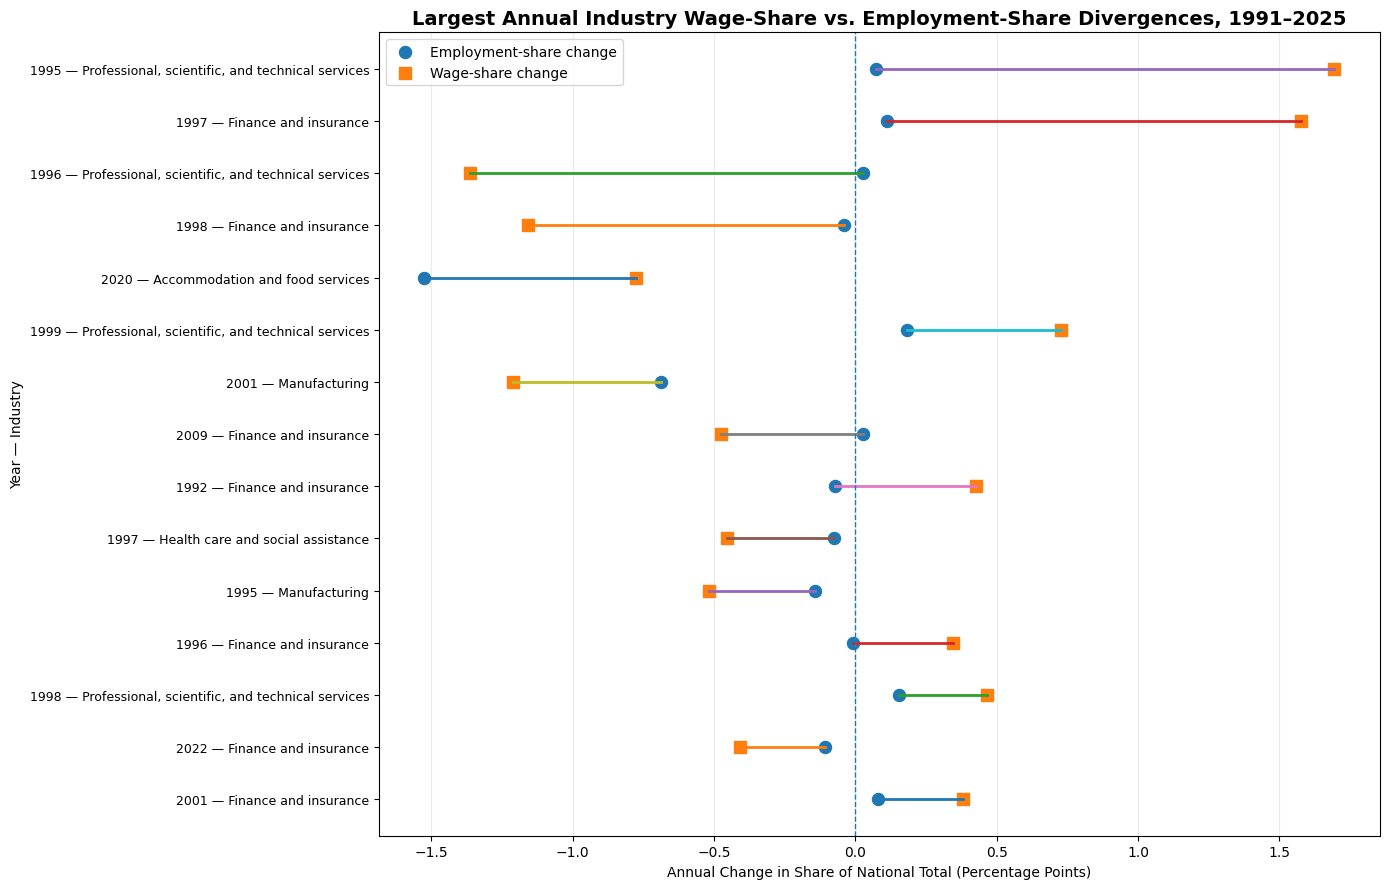

In [70]:
# Dumbbell chart — largest annual industry
# wage-share vs employment-share divergences

dumbbell_plot = (
    annual_industry_divergence
    .head(15)
    .copy()
)

# Clean industry titles
dumbbell_plot["clean_industry_title"] = (
    dumbbell_plot["industry_title"]
    .str.replace(
        r"^NAICS\s+[0-9\-]+\s+",
        "",
        regex=True
    )
)

# Create readable labels
dumbbell_plot["label"] = (
    dumbbell_plot["year"].astype(int).astype(str)
    + " — "
    + dumbbell_plot["clean_industry_title"]
)

# Sort by absolute divergence so largest is at top
dumbbell_plot = dumbbell_plot.sort_values(
    "absolute_shift_pp",
    ascending=True
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 9))

y = range(len(dumbbell_plot))

# Connecting lines
for i, row in dumbbell_plot.iterrows():
    ax.plot(
        [
            row["employment_share_change_yoy_pp"],
            row["wage_share_change_yoy_pp"]
        ],
        [i, i],
        linewidth=2
    )

# Employment-share points
ax.scatter(
    dumbbell_plot["employment_share_change_yoy_pp"],
    y,
    s=75,
    marker="o",
    label="Employment-share change"
)

# Wage-share points
ax.scatter(
    dumbbell_plot["wage_share_change_yoy_pp"],
    y,
    s=75,
    marker="s",
    label="Wage-share change"
)

# Zero reference line
ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

# Labels
ax.set_yticks(list(y))
ax.set_yticklabels(
    dumbbell_plot["label"],
    fontsize=9
)

ax.set_title(
    "Largest Annual Industry Wage-Share vs. Employment-Share Divergences, 1991–2025",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Annual Change in Share of National Total (Percentage Points)"
)

ax.set_ylabel("Year — Industry")

ax.grid(
    axis="x",
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

### Annual Industry Wage-Share vs. Employment-Share Divergence — Interpretation

This chart compares the annual change in each industry's **share of national employment** with the annual change in its **share of the national wage pool** for the largest observed Year × Industry divergences.

Each row represents one specific industry in one specific year.

- The **circle** shows the industry's year-over-year change in employment share.
- The **square** shows the industry's year-over-year change in wage share.
- The horizontal line connecting them represents the size of the divergence between those two movements.
- The vertical zero line separates increases from decreases in national share.

The underlying measure is:

**Annual Wage-vs-Employment Shift = Wage-Share Change − Employment-Share Change**

A large separation between the two markers indicates that the industry's wage share moved substantially differently from its employment share during that year.

Examples from the largest divergences include:

- **1995 — Professional, Scientific, and Technical Services:** employment share changed only slightly, while wage share increased sharply. This produced one of the largest positive wage-vs-employment divergences in the full annual series.
- **1996 — Professional, Scientific, and Technical Services:** employment share again changed very little, while wage share declined sharply, producing a large divergence in the opposite direction.
- **1997 — Finance and Insurance:** wage share increased substantially more than employment share.
- **1998 — Finance and Insurance:** wage share declined substantially more than employment share.
- **2020 — Accommodation and Food Services:** both employment share and wage share declined, but employment share fell considerably more, indicating that the industry's employment distribution shifted more sharply than its wage distribution.

The chart therefore distinguishes several possible forms of divergence:

1. **Wage share increases more than employment share**
2. **Wage share decreases more than employment share**
3. **Employment share declines more than wage share**
4. **Employment share increases more than wage share**

The visualization does not measure absolute job creation or total wage growth. Instead, it shows how differently an industry's **relative share of workers** and **relative share of wages** changed from one year to the next.

These results are descriptive and identify **where the largest annual disconnects between employment distribution and wage distribution occurred**. They do not establish the causes of those differences.

In [72]:
# Validate unusual late-1990s wage-share movements
# NAICS 54: Professional, Scientific & Technical Services
# NAICS 52: Finance & Insurance

late_90s_validation = (
    sector_annual_real[
        sector_annual_real["industry_code"].isin(["52", "54"])
        & sector_annual_real["year"].between(1993, 2000)
    ]
    [
        [
            "year",
            "industry_code",
            "industry_title",
            "sector_employment",
            "sector_wages",
            "employment_share_pct",
            "wage_share_pct",
            "avg_annual_pay",
            "real_avg_annual_pay_2025_dollars",
            "employment_share_change_yoy_pp",
            "wage_share_change_yoy_pp"
        ]
    ]
    .sort_values(
        ["industry_code", "year"]
    )
)

late_90s_validation

,year,industry_code,industry_title,sector_employment,sector_wages,employment_share_pct,wage_share_pct,avg_annual_pay,real_avg_annual_pay_2025_dollars,employment_share_change_yoy_pp,wage_share_change_yoy_pp
69,1993,52,NAICS 52 Finance and insurance,4968771.0,1.925274e+11,4.541755,6.667072,38747.480056,86408.752131,-0.045510,0.020371
89,1994,52,NAICS 52 Finance and insurance,5029004.0,1.941912e+11,4.470139,6.396067,38614.238472,83933.046794,-0.071616,-0.271005
109,1995,52,NAICS 52 Finance and insurance,4964701.0,2.063785e+11,4.301633,6.308811,41569.177145,87890.296889,-0.168506,-0.087256
129,1996,52,NAICS 52 Finance and insurance,5057766.0,2.272030e+11,4.292838,6.653042,44921.613606,92268.768639,-0.008796,0.344231
149,1997,52,NAICS 52 Finance and insurance,5329980.0,3.074432e+11,4.404170,8.228329,57681.874587,115772.033190,0.111332,1.575287
169,1998,52,NAICS 52 Finance and insurance,5412813.0,2.806702e+11,4.362445,7.072162,51852.931784,102487.401644,-0.041725,-1.156167
189,1999,52,NAICS 52 Finance and insurance,5550031.0,3.044557e+11,4.371381,7.161725,54856.584062,106097.264207,0.008936,0.089562
209,2000,52,NAICS 52 Finance and insurance,5578028.0,3.353142e+11,4.294769,7.307227,60113.387275,112477.600719,-0.076613,0.145502
71,1993,54,"NAICS 54 Professional, scientific, and technic...",5112813.0,2.005865e+11,4.673418,6.946154,39232.123106,87489.529544,0.028292,0.027685
91,1994,54,"NAICS 54 Professional, scientific, and technic...",5241069.0,2.118802e+11,4.658637,6.978691,40426.907169,87873.116896,-0.014780,0.032536


### Historical QCEW Comparability Note — Pre-2001 Observations

The analysis identified unusually large wage-share movements during the late 1990s, particularly within **Professional, Scientific, and Technical Services (NAICS 54)** and **Finance and Insurance (NAICS 52)**.

Validation confirmed that these movements are present in the underlying QCEW sector wage and employment values and are **not artifacts introduced by the AEDR analytical calculations**. The observations are therefore retained and reported as published.

**Historical Comparability Disclaimer:** QCEW industry data prior to 2001 were originally classified under the Standard Industrial Classification (SIC) system and were subsequently reconstructed by the Bureau of Labor Statistics into historical NAICS-based data. Accordingly, pre-2001 industry comparisons may be subject to additional classification and reconstruction limitations.

This analysis does not assume that the historical reconstruction caused the observed wage-share movements, nor does it assume that the movements are entirely unaffected by reconstruction. The findings are reported descriptively as they appear in the published data, with this limitation noted for appropriate interpretation.

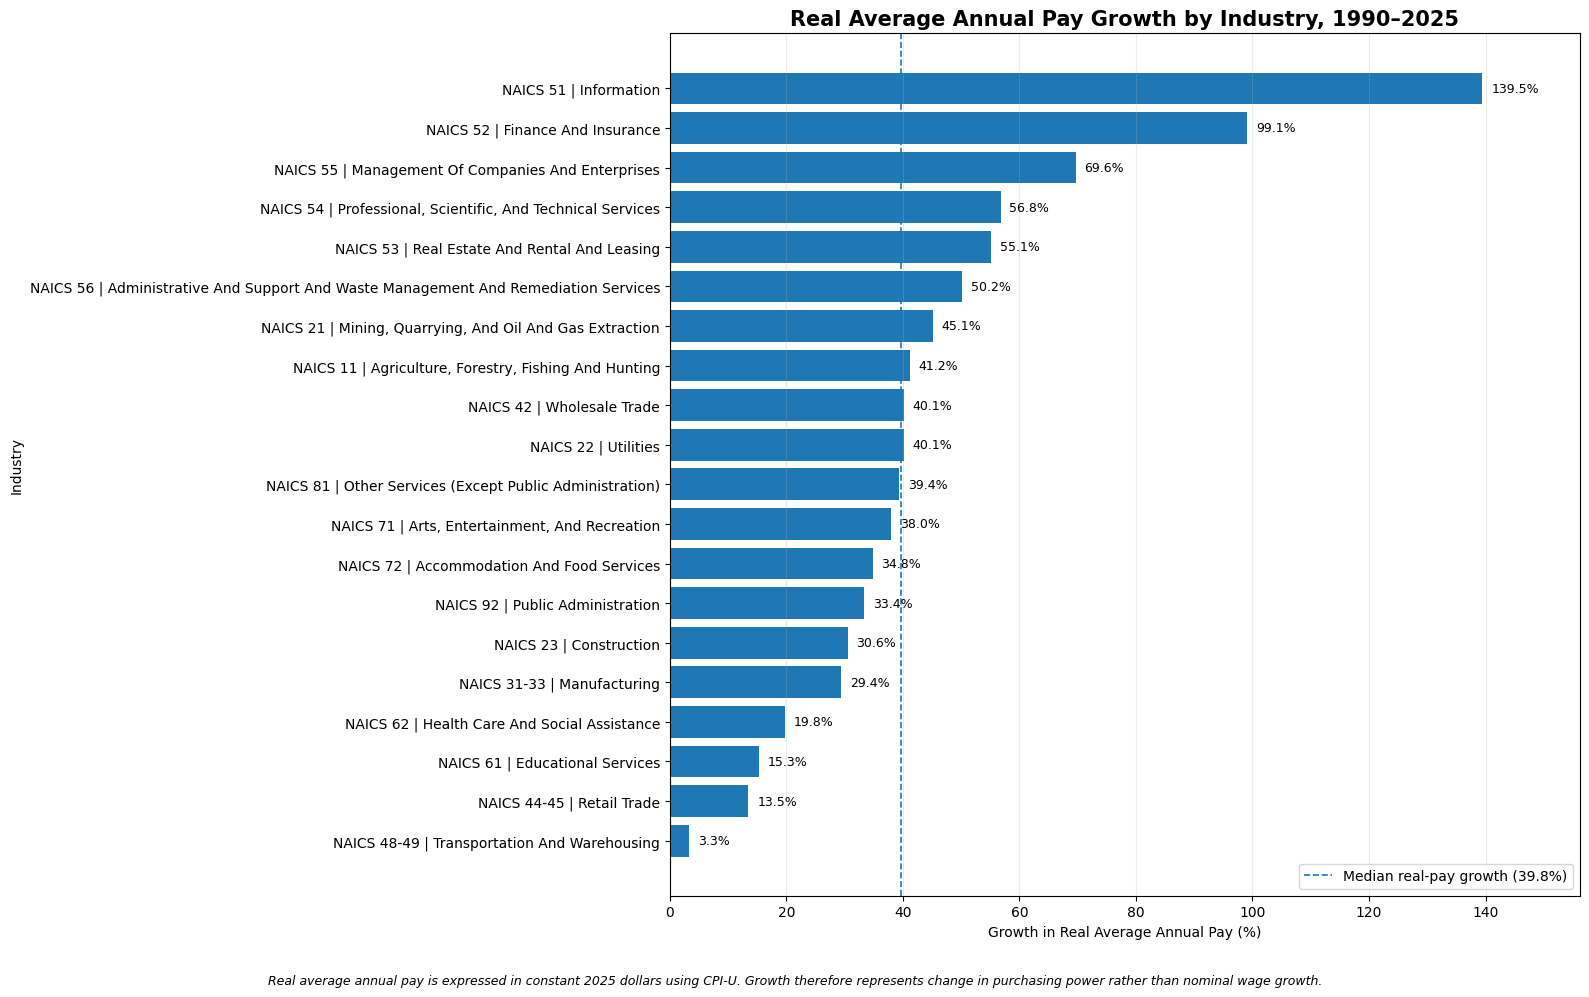

In [86]:
# ============================================================
# SUMMARY VISUAL
# Real Average Annual Pay Growth by Industry, 1990–2025
#
# Label format:
# NAICS 54 | Professional, Scientific, and Technical Services
# ============================================================

import matplotlib.pyplot as plt

# Use validated endpoint results
real_pay_summary = (
    where_money_went
    .dropna(subset=["real_pay_growth_pct"])
    .copy()
)

# ------------------------------------------------------------
# Create presentation labels
# Example:
# NAICS 54 | Professional, Scientific, and Technical Services
# ------------------------------------------------------------

# Remove existing "NAICS ## " prefix from industry title
real_pay_summary["clean_title"] = (
    real_pay_summary["industry_title"]
    .str.replace(
        r"^NAICS\s+[0-9\-]+\s+",
        "",
        regex=True
    )
)

# Convert title to presentation-style capitalization
real_pay_summary["clean_title"] = (
    real_pay_summary["clean_title"]
    .str.title()
)

# Build final label
real_pay_summary["plot_label"] = (
    "NAICS "
    + real_pay_summary["industry_code"].astype(str)
    + " | "
    + real_pay_summary["clean_title"]
)

# Sort lowest to highest so largest growth appears at top
real_pay_summary = (
    real_pay_summary
    .sort_values(
        "real_pay_growth_pct",
        ascending=True
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 10))

bars = ax.barh(
    real_pay_summary["plot_label"],
    real_pay_summary["real_pay_growth_pct"]
)

# Percentage labels
for bar, value in zip(
    bars,
    real_pay_summary["real_pay_growth_pct"]
):
    ax.text(
        value + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

# ------------------------------------------------------------
# Median reference line
# ------------------------------------------------------------

median_real_pay_growth = (
    real_pay_summary["real_pay_growth_pct"].median()
)

ax.axvline(
    median_real_pay_growth,
    linestyle="--",
    linewidth=1.2,
    label=f"Median real-pay growth ({median_real_pay_growth:.1f}%)"
)

# ------------------------------------------------------------
# Titles and formatting
# ------------------------------------------------------------

ax.set_title(
    "Real Average Annual Pay Growth by Industry, 1990–2025",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Growth in Real Average Annual Pay (%)"
)

ax.set_ylabel(
    "Industry"
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.legend(
    loc="lower right"
)

ax.set_xlim(
    0,
    real_pay_summary["real_pay_growth_pct"].max() * 1.12
)

# ------------------------------------------------------------
# Methodology note
# ------------------------------------------------------------

fig.text(
    0.50,
    0.01,
    (
        "Real average annual pay is expressed in constant 2025 dollars "
        "using CPI-U. Growth therefore represents change in purchasing "
        "power rather than nominal wage growth."
    ),
    ha="center",
    fontsize=9,
    style="italic"
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

### Summary — Real Pay Growth Across Industries

From 1990 to 2025, **real average annual pay increased across every comparable NAICS industry**, indicating that average annual pay ultimately outpaced consumer-price inflation across all industries included in the full-period comparison.

The magnitude of these gains, however, was highly uneven. The median industry experienced approximately **40% growth in real average annual pay**, while individual outcomes ranged from roughly **3% in Transportation and Warehousing** to approximately **139% in Information**.

The strongest long-run real-pay gains were concentrated in industries such as **Information, Finance and Insurance, Management of Companies and Enterprises, and Professional, Scientific, and Technical Services**. In contrast, industries including **Transportation and Warehousing, Retail Trade, Educational Services, and Health Care and Social Assistance** experienced substantially smaller improvements in real average annual pay.

Overall, the results show that the question of **"Where has the money gone?"** is not characterized by a general decline in inflation-adjusted average pay. Rather, the principal finding is the **uneven distribution of real-pay growth across industries**: purchasing power improved across the entire comparable industry set, but some industries captured dramatically larger improvements than others.